In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')
import plotly.graph_objs as go
from scipy import stats

# data understanding

About this file Training set for Credit Card Transactions 1.index - Unique Identifier for each row 2.transdatetrans_time - Transaction DateTime 3.cc_num - Credit Card Number of Customer 4.merchant - Merchant Name 5.category - Category of Merchant 6.amt - Amount of Transaction 7.first - First Name of Credit Card Holder 8.last - Last Name of Credit Card Holder 9.gender - Gender of Credit Card Holder 10.street - Street Address of Credit Card Holder 11.city - City of Credit Card Holder 12.state - State of Credit Card Holder 13.zip - Zip of Credit Card Holder 14.lat - Latitude Location of Credit Card Holder 15.long - Longitude Location of Credit Card Holder 16.city_pop - Credit Card Holder's City Population 17.job - Job of Credit Card Holder 18.dob - Date of Birth of Credit Card Holder 19.trans_num - Transaction Number 20.unix_time - UNIX Time of transaction 21.merch_lat - Latitude Location of Merchant 22.merch_long - Longitude Location of Merchant 23.is_fraud - Fraud Flag <--- Target Class

# Reading the Dataset

In [2]:
df=pd.read_csv(r"C:\Users\SOBITACHI\Downloads\CAPSTONE PROJECT DATASET\Finance Dataset\fraudTest.csv", index_col=0)
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


# Data Dictionary

checking shape of the dataset

In [3]:
df.shape

(555719, 22)

checking the datatypes

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  555719 non-null  object 
 1   cc_num                 555719 non-null  int64  
 2   merchant               555719 non-null  object 
 3   category               555719 non-null  object 
 4   amt                    555719 non-null  float64
 5   first                  555719 non-null  object 
 6   last                   555719 non-null  object 
 7   gender                 555719 non-null  object 
 8   street                 555719 non-null  object 
 9   city                   555719 non-null  object 
 10  state                  555719 non-null  object 
 11  zip                    555719 non-null  int64  
 12  lat                    555719 non-null  float64
 13  long                   555719 non-null  float64
 14  city_pop               555719 non-nu

In [5]:
len(df.select_dtypes(include='number').columns)

10

In [6]:
len(df.select_dtypes(include='object').columns)

12

# Changing Datatypes for required columns

In [7]:
df['trans_date_trans_time']=pd.to_datetime(df['trans_date_trans_time'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 555719 entries, 0 to 555718
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  555719 non-null  datetime64[ns]
 1   cc_num                 555719 non-null  int64         
 2   merchant               555719 non-null  object        
 3   category               555719 non-null  object        
 4   amt                    555719 non-null  float64       
 5   first                  555719 non-null  object        
 6   last                   555719 non-null  object        
 7   gender                 555719 non-null  object        
 8   street                 555719 non-null  object        
 9   city                   555719 non-null  object        
 10  state                  555719 non-null  object        
 11  zip                    555719 non-null  int64         
 12  lat                    555719 non-null  floa

checking for missing values

In [9]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

Descriptive Summary

In [10]:
# For Numerrical columns
df.describe(include='number')

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [11]:
# For Categorical Columns
df.describe(include='object')

,merchant,category,first,last,gender,street,city,state,job,dob,trans_num
count,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719,555719
unique,693,14,341,471,2,924,849,50,478,910,555719
top,fraud_Kilback LLC,gas_transport,Christopher,Smith,F,444 Robert Mews,Birmingham,TX,Film/video editor,1977-03-23,2da90c7d74bd46a0caf3777415b3ebd3
freq,1859,56370,11443,12146,304886,1474,2423,40393,4119,2408,1


# Checking For Outliers

In [12]:
df_out=df.drop(columns=['trans_date_trans_time','is_fraud','cc_num'])

In [13]:
df_out.columns

Index(['merchant', 'category', 'amt', 'first', 'last', 'gender', 'street',
       'city', 'state', 'zip', 'lat', 'long', 'city_pop', 'job', 'dob',
       'trans_num', 'unix_time', 'merch_lat', 'merch_long'],
      dtype='object')

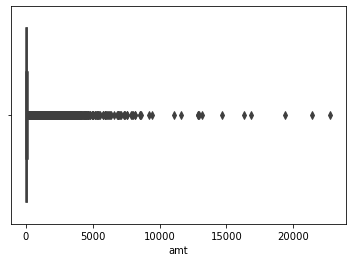

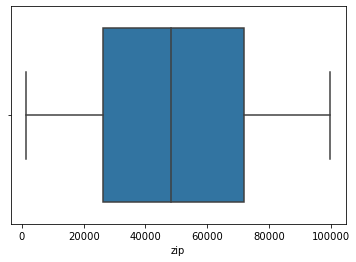

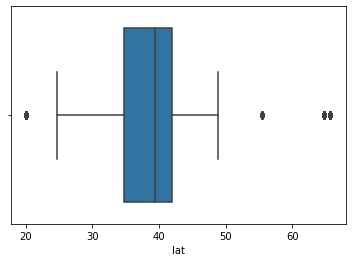

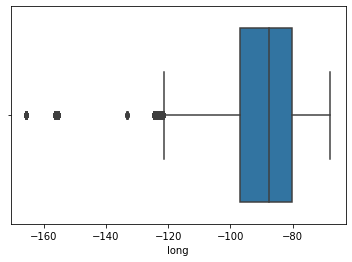

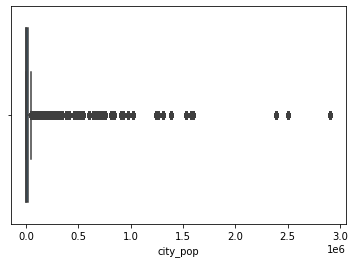

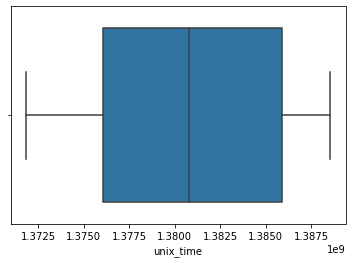

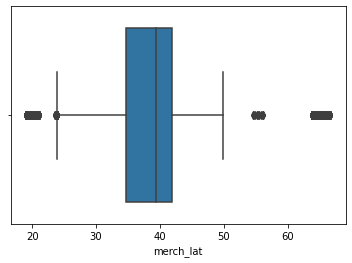

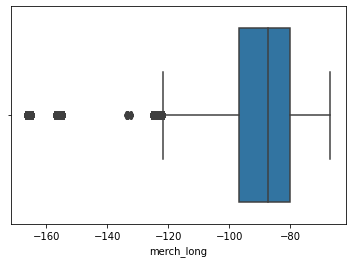

In [14]:
c=1
for i in df_out.select_dtypes(include='number').columns:
    sns.boxplot(df_out[i])
    c+=1
    plt.show()

# Checking Multicollinearity

In [15]:
df_n=df.select_dtypes(include='number').drop(columns=['cc_num','is_fraud'])

In [16]:
df_n

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long
0,2.86,29209,33.9659,-80.9355,333497,1371816865,33.986391,-81.200714
1,29.84,84002,40.3207,-110.4360,302,1371816873,39.450498,-109.960431
2,41.28,11710,40.6729,-73.5365,34496,1371816893,40.495810,-74.196111
3,60.05,32780,28.5697,-80.8191,54767,1371816915,28.812398,-80.883061
4,3.19,49632,44.2529,-85.0170,1126,1371816917,44.959148,-85.884734
...,...,...,...,...,...,...,...,...
555714,43.77,63453,40.4931,-91.8912,519,1388534347,39.946837,-91.333331
555715,111.84,77566,29.0393,-95.4401,28739,1388534349,29.661049,-96.186633
555716,86.88,99323,46.1966,-118.9017,3684,1388534355,46.658340,-119.715054
555717,7.99,83643,44.6255,-116.4493,129,1388534364,44.470525,-117.080888


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X=df_n
vif = pd.DataFrame()
vif["VIF_Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["Features"] = X.columns
print(vif)

   VIF_Factor    Features
0    1.000017         amt
1    6.411975         zip
2   77.959500         lat
3  570.956798        long
4    1.027424    city_pop
5  168.537981   unix_time
6   77.852292   merch_lat
7  565.465029  merch_long


In [18]:
vif.sort_values(by=["VIF_Factor"],ascending=False)

,VIF_Factor,Features
3,570.956798,long
7,565.465029,merch_long
5,168.537981,unix_time
2,77.959500,lat
6,77.852292,merch_lat
1,6.411975,zip
4,1.027424,city_pop
0,1.000017,amt


Converting Trans_Date_trans_Time to dayofweek, day_name, week, day, minute, hour, month_name, month, year and dayaofyear

In [19]:
df['weekday_no'] = df['trans_date_trans_time'].dt.dayofweek
df['week_day'] = df['trans_date_trans_time'].dt.day_name()
df['week_no'] = df['trans_date_trans_time'].dt.week
df['day_no'] = df['trans_date_trans_time'].dt.day
df['min_day'] = df['trans_date_trans_time'].dt.minute
df['hr_day'] = df['trans_date_trans_time'].dt.hour
df['month_name'] = df['trans_date_trans_time'].dt.month_name()
df['month'] = df['trans_date_trans_time'].dt.month
df['year'] = df['trans_date_trans_time'].dt.year
df['year_dayno'] = df['trans_date_trans_time'].dt.dayofyear

In [20]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,weekday_no,week_day,week_no,day_no,min_day,hr_day,month_name,month,year,year_dayno
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,6,Sunday,25,21,14,12,June,6,2020,173
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,6,Sunday,25,21,14,12,June,6,2020,173


In [21]:
df.iloc[:,-12:-1]

,merch_long,is_fraud,weekday_no,week_day,week_no,day_no,min_day,hr_day,month_name,month,year
0,-81.200714,0,6,Sunday,25,21,14,12,June,6,2020
1,-109.960431,0,6,Sunday,25,21,14,12,June,6,2020
2,-74.196111,0,6,Sunday,25,21,14,12,June,6,2020
3,-80.883061,0,6,Sunday,25,21,15,12,June,6,2020
4,-85.884734,0,6,Sunday,25,21,15,12,June,6,2020
...,...,...,...,...,...,...,...,...,...,...,...
555714,-91.333331,0,3,Thursday,53,31,59,23,December,12,2020
555715,-96.186633,0,3,Thursday,53,31,59,23,December,12,2020
555716,-119.715054,0,3,Thursday,53,31,59,23,December,12,2020
555717,-117.080888,0,3,Thursday,53,31,59,23,December,12,2020


Convrting DOB to no. of year

In [22]:
df['dob']=pd.to_datetime(df['dob'])

In [23]:
df['no_of_years']=pd.DatetimeIndex(df['dob']).year

In [24]:
df['no_of_years']=2022-df['no_of_years']

In [25]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,week_day,week_no,day_no,min_day,hr_day,month_name,month,year,year_dayno,no_of_years
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,Sunday,25,21,14,12,June,6,2020,173,54
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,Sunday,25,21,14,12,June,6,2020,173,32


In [26]:
df['no_of_years'].unique()

array([54, 32, 52, 35, 67, 31, 71, 50, 49, 66, 26, 46, 45, 85, 51, 34, 30,
       25, 37, 65, 74, 92, 48, 58, 64, 27, 42, 53, 47, 61, 79, 43, 36, 28,
       93, 88, 29, 23, 40, 24, 38, 44, 33, 55, 22, 73, 84, 56, 57, 77, 39,
       18, 70, 41, 72, 19, 68, 62, 81, 60, 76, 69, 98, 59, 21, 63, 96, 75,
       86, 87, 83, 80, 17, 78, 91, 95, 82, 94, 89, 90, 20], dtype=int64)

In [27]:
def function_mrp(a):
    if a <=25 :
        return 'Very young age'
    if a > 25 and a <= 35:
        return 'Young age'
    if a > 35 and a <= 45:
        return 'Middle age'
    else:
        return 'Senior citizen'

In [28]:
df['age_group'] = df['no_of_years'].apply(function_mrp)

In [29]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,week_no,day_no,min_day,hr_day,month_name,month,year,year_dayno,no_of_years,age_group
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,25,21,14,12,June,6,2020,173,54,Senior citizen
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,25,21,14,12,June,6,2020,173,32,Young age


In [30]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'weekday_no', 'week_day', 'week_no', 'day_no',
       'min_day', 'hr_day', 'month_name', 'month', 'year', 'year_dayno',
       'no_of_years', 'age_group'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 555719 entries, 0 to 555718
Data columns (total 34 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   trans_date_trans_time  555719 non-null  datetime64[ns]
 1   cc_num                 555719 non-null  int64         
 2   merchant               555719 non-null  object        
 3   category               555719 non-null  object        
 4   amt                    555719 non-null  float64       
 5   first                  555719 non-null  object        
 6   last                   555719 non-null  object        
 7   gender                 555719 non-null  object        
 8   street                 555719 non-null  object        
 9   city                   555719 non-null  object        
 10  state                  555719 non-null  object        
 11  zip                    555719 non-null  int64         
 12  lat                    555719 non-null  floa

In [32]:
df.is_fraud.unique()

array([0, 1], dtype=int64)

# Counting the no. of outliers by columns

In [33]:
df_out=df.drop(columns=['trans_date_trans_time','cc_num','dob', 'is_fraud'])

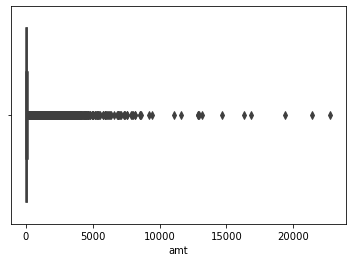

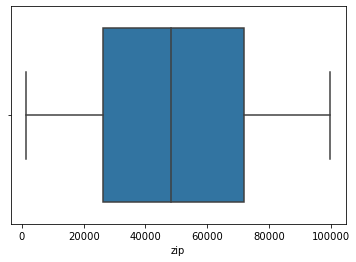

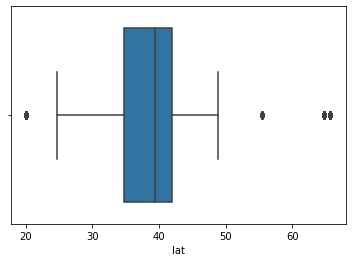

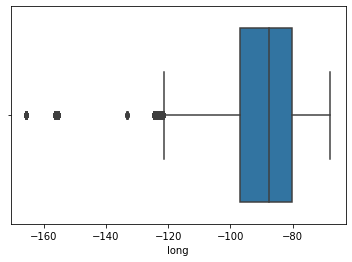

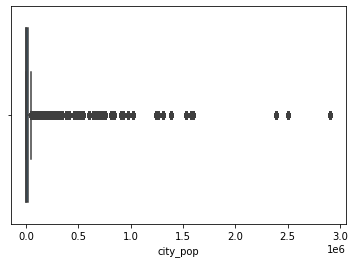

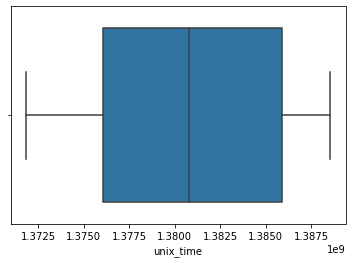

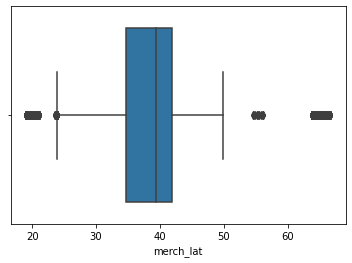

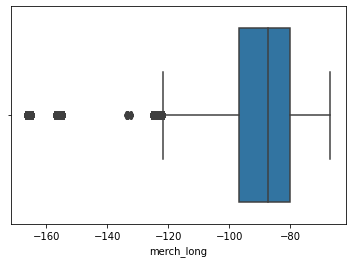

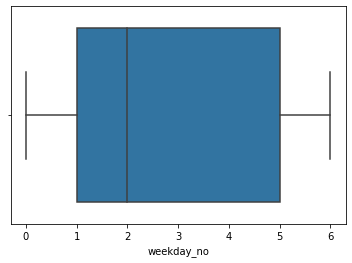

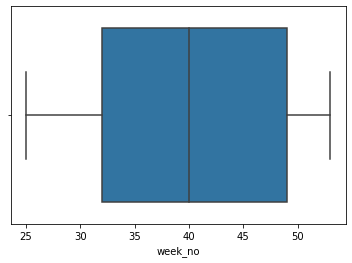

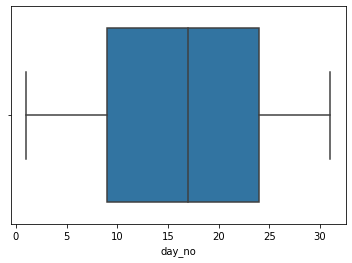

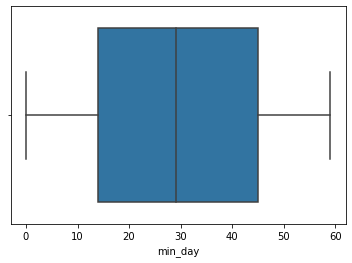

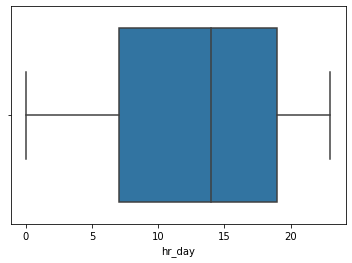

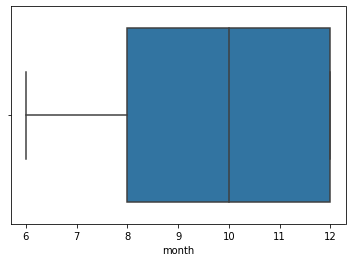

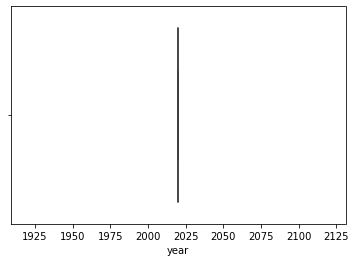

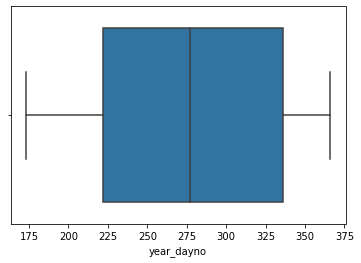

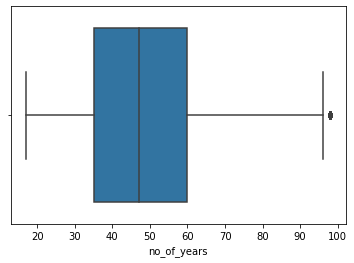

In [34]:
c=1
for i in df_out.select_dtypes(include='number').columns:
    sns.boxplot(df[i])
    c+=1
    plt.show()

In [35]:
def find_outliers_IQR(df):
    q1=df.quantile(0.25)
    q3=df.quantile(0.75)
    IQR=q3-q1
    outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]
    return outliers

In [36]:
print(' no. of outliers in lat ')
outliers = find_outliers_IQR(df['lat'])
print('number of outliers:'+ str(len(outliers)))

print('max outlier value:'+ str(outliers.max()))

print('min outlier value:' + str(outliers.min()))

 no. of outliers in lat 
number of outliers:1933
max outlier value:65.6899
min outlier value:20.0271


In [37]:
print(' no. of outliers in long')
outliers = find_outliers_IQR(df['long'])
print('number of outliers:'+ str(len(outliers)))

print('max outlier value:'+ str(outliers.max()))

print('min outlier value:' + str(outliers.min()))

 no. of outliers in long
number of outliers:21104
max outlier value:-121.7913
min outlier value:-165.6723


In [38]:
print(' no. of outliers in city_pop')
outliers = find_outliers_IQR(df['city_pop'])
print('number of outliers:'+ str(len(outliers)))

print('max outlier value:'+ str(outliers.max()))

print('min outlier value:' + str(outliers.min()))

 no. of outliers in city_pop
number of outliers:104151
max outlier value:2906700
min outlier value:48194


In [39]:
print(' no. of outliers in merch_lat')
outliers = find_outliers_IQR(df['merch_lat'])
print('number of outliers:'+ str(len(outliers)))

print('max outlier value:'+ str(outliers.max()))

print('min outlier value:' + str(outliers.min()))

 no. of outliers in merch_lat
number of outliers:2090
max outlier value:66.67929699999999
min outlier value:19.027422


In [40]:
print(' no. of outliers in merch_long')
outliers = find_outliers_IQR(df['merch_long'])
print('number of outliers:'+ str(len(outliers)))

print('max outlier value:'+ str(outliers.max()))

print('min outlier value:' + str(outliers.min()))

 no. of outliers in merch_long
number of outliers:17926
max outlier value:-121.865916
min outlier value:-166.671575


In [41]:
print(' no. of outliers in no_of_years')
outliers = find_outliers_IQR(df['no_of_years'])
print('number of outliers:'+ str(len(outliers)))

print('max outlier value:'+ str(outliers.max()))

print('min outlier value:' + str(outliers.min()))

 no. of outliers in no_of_years
number of outliers:199
max outlier value:98
min outlier value:98


# Counting the no of outliers by rows

In [42]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,week_no,day_no,min_day,hr_day,month_name,month,year,year_dayno,no_of_years,age_group
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,25,21,14,12,June,6,2020,173,54,Senior citizen
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,25,21,14,12,June,6,2020,173,32,Young age


# Dropping columns that are not relevant

In [43]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud', 'weekday_no', 'week_day', 'week_no', 'day_no',
       'min_day', 'hr_day', 'month_name', 'month', 'year', 'year_dayno',
       'no_of_years', 'age_group'],
      dtype='object')

In [44]:
df.drop(columns=['trans_date_trans_time','cc_num','dob'], inplace=True)

# Exploratory Data Analysis

# Univariate analysis for numerical columns

In [45]:
df_n

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long
0,2.86,29209,33.9659,-80.9355,333497,1371816865,33.986391,-81.200714
1,29.84,84002,40.3207,-110.4360,302,1371816873,39.450498,-109.960431
2,41.28,11710,40.6729,-73.5365,34496,1371816893,40.495810,-74.196111
3,60.05,32780,28.5697,-80.8191,54767,1371816915,28.812398,-80.883061
4,3.19,49632,44.2529,-85.0170,1126,1371816917,44.959148,-85.884734
...,...,...,...,...,...,...,...,...
555714,43.77,63453,40.4931,-91.8912,519,1388534347,39.946837,-91.333331
555715,111.84,77566,29.0393,-95.4401,28739,1388534349,29.661049,-96.186633
555716,86.88,99323,46.1966,-118.9017,3684,1388534355,46.658340,-119.715054
555717,7.99,83643,44.6255,-116.4493,129,1388534364,44.470525,-117.080888


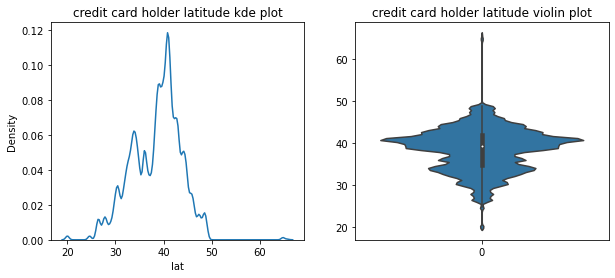

In [46]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('credit card holder latitude kde plot')
sns.kdeplot(data=df_n['lat'])

#  subplot #2
plt.subplot(122)
plt.title('credit card holder latitude violin plot')
sns.violinplot(data=df_n['lat'])

plt.show()

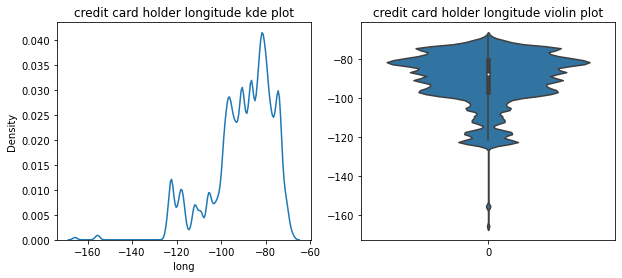

In [47]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('credit card holder longitude kde plot')
sns.kdeplot(data=df_n['long'])

#  subplot #2
plt.subplot(122)
plt.title('credit card holder longitude violin plot')
sns.violinplot(data=df_n['long'])

plt.show()

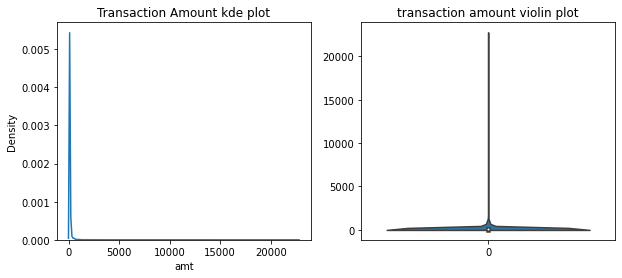

In [48]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('Transaction Amount kde plot')
sns.kdeplot(data=df_n['amt'])

#  subplot #2
plt.subplot(122)
plt.title('transaction amount violin plot')
sns.violinplot(data=df_n['amt'])

plt.show()

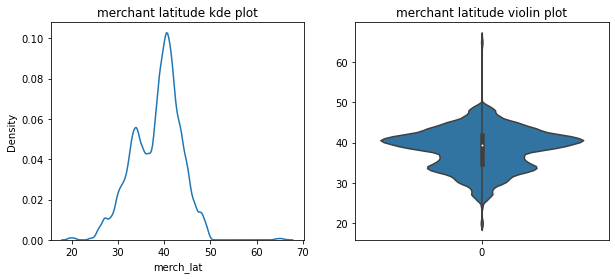

In [49]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('merchant latitude kde plot')
sns.kdeplot(data=df_n['merch_lat'])

#  subplot #2
plt.subplot(122)
plt.title('merchant latitude violin plot')
sns.violinplot(data=df_n['merch_lat'])

plt.show()

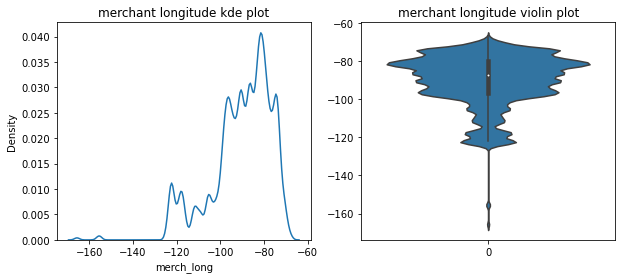

In [50]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('merchant longitude kde plot')
sns.kdeplot(data=df_n['merch_long'])

#  subplot #2
plt.subplot(122)
plt.title('merchant longitude violin plot')
sns.violinplot(data=df_n['merch_long'])

plt.show()

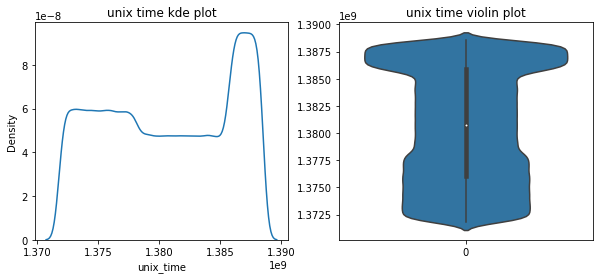

In [51]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('unix time kde plot')
sns.kdeplot(data=df_n['unix_time'])

#  subplot #2
plt.subplot(122)
plt.title('unix time violin plot')
sns.violinplot(data=df_n['unix_time'])

plt.show()

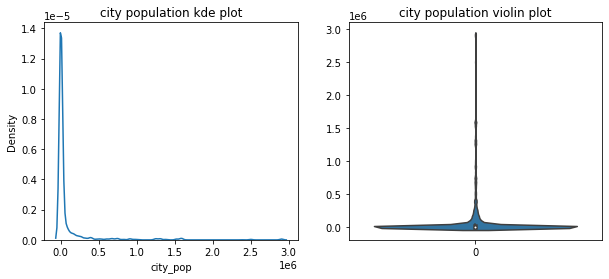

In [52]:
fig = plt.figure(figsize=(10,4))

#  subplot #1
plt.subplot(121)
plt.title('city population kde plot')
sns.kdeplot(data=df_n['city_pop'])

#  subplot #2
plt.subplot(122)
plt.title('city population violin plot')
sns.violinplot(data=df_n['city_pop'])

plt.show()

# univariate analysis for categorical columns

In [53]:
df_cat=df.select_dtypes(include='object')
df_cat.head(2)

,merchant,category,first,last,gender,street,city,state,job,trans_num,week_day,month_name,age_group
0,fraud_Kirlin and Sons,personal_care,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,Mechanical engineer,2da90c7d74bd46a0caf3777415b3ebd3,Sunday,June,Senior citizen
1,fraud_Sporer-Keebler,personal_care,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,"Sales professional, IT",324cc204407e99f51b0d6ca0055005e7,Sunday,June,Young age


For Merchant Column

In [54]:
df_cat['merchant'].value_counts().head(10)

fraud_Kilback LLC                 1859
fraud_Cormier LLC                 1597
fraud_Schumm PLC                  1561
fraud_Kuhn LLC                    1521
fraud_Dickinson Ltd               1519
fraud_Boyer PLC                   1506
fraud_Emard Inc                   1226
fraud_Parisian and Sons           1202
fraud_Corwin-Collins              1178
fraud_Streich, Hansen and Veum    1168
Name: merchant, dtype: int64

<AxesSubplot:>

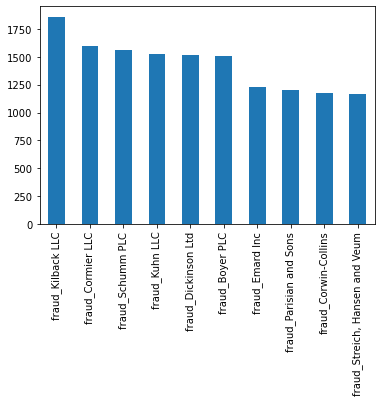

In [55]:
df_cat['merchant'].value_counts().head(10).plot(kind='bar')

For Category Column

In [56]:
df_cat['category'].value_counts()

gas_transport     56370
grocery_pos       52553
home              52345
shopping_pos      49791
kids_pets         48692
shopping_net      41779
entertainment     40104
personal_care     39327
food_dining       39268
health_fitness    36674
misc_pos          34574
misc_net          27367
grocery_net       19426
travel            17449
Name: category, dtype: int64

<AxesSubplot:>

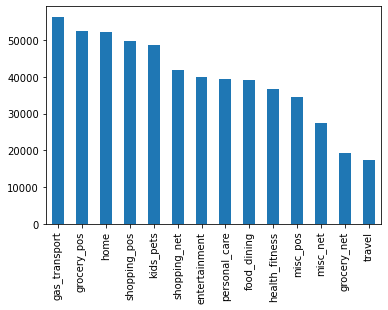

In [57]:
df_cat['category'].value_counts().plot(kind='bar')

For City Column

In [58]:
df_cat['city'].value_counts().head(10)

Birmingham     2423
Meridian       2229
Phoenix        2222
Utica          2204
San Antonio    2182
Warren         1985
Cleveland      1968
Conway         1961
Thomas         1937
Fulton         1864
Name: city, dtype: int64

<AxesSubplot:>

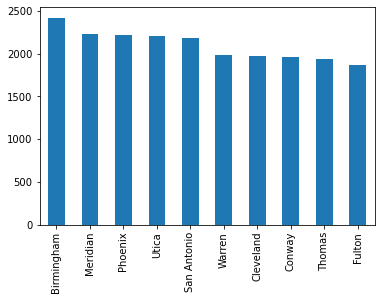

In [59]:
df_cat['city'].value_counts().head(10).plot(kind='bar')

For State Column

In [60]:
df_cat['state'].value_counts().head(10)

TX    40393
NY    35918
PA    34326
CA    24135
OH    20147
MI    19671
IL    18960
FL    18104
AL    17532
MO    16501
Name: state, dtype: int64

<AxesSubplot:>

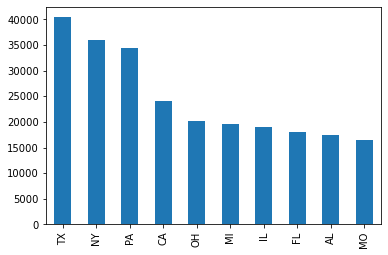

In [61]:
df_cat['state'].value_counts().head(10).plot(kind='bar')

For Job Column

In [62]:
df_cat['job'].value_counts().head(10)

Film/video editor             4119
Exhibition designer           3968
Surveyor, land/geomatics      3756
Naval architect               3750
Designer, ceramics/pottery    3463
Materials engineer            3441
Environmental consultant      3427
Financial adviser             3304
IT trainer                    3264
Systems developer             3262
Name: job, dtype: int64

<AxesSubplot:>

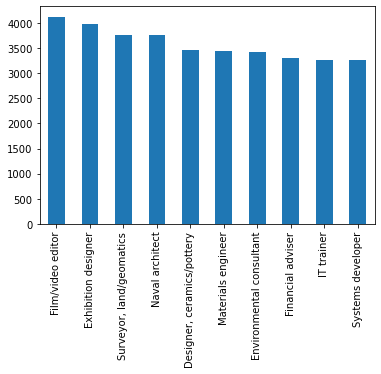

In [63]:
df_cat['job'].value_counts().head(10).plot(kind='bar')

for age column

In [64]:
df_cat['age_group'].value_counts()

Senior citizen    294790
Middle age        117591
Young age         102649
Very young age     40689
Name: age_group, dtype: int64

<AxesSubplot:>

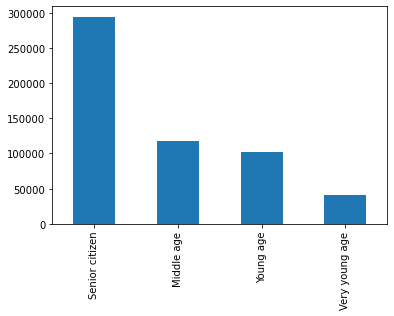

In [65]:
df_cat['age_group'].value_counts().plot(kind="bar")

# checking the data imbalance ratio

In [66]:
target0 = df.loc[df['is_fraud']==0]
target1 = df.loc[df['is_fraud']==1]

In [67]:
df['is_fraud'].value_counts()
(df['is_fraud'].value_counts()/len(df['is_fraud']))*100

0    99.614014
1     0.385986
Name: is_fraud, dtype: float64

In [68]:
round(len(target0)/len(target1),2)

258.08

Ratio of credit card non defaulters to defaulters

In [69]:
m=np.array(df['is_fraud'].value_counts())

([<matplotlib.patches.Wedge at 0x21d40faad60>,
 [Text(-1.0999191268840707, 0.013338452480854692, 'no_defaulters'),
  Text(1.0999191263279473, -0.01333849833996486, 'defaulters')],
 [Text(-0.5999558873913112, 0.007275519535011649, '99.61'),
  Text(0.5999558870879712, -0.007275544549071741, '0.39')])

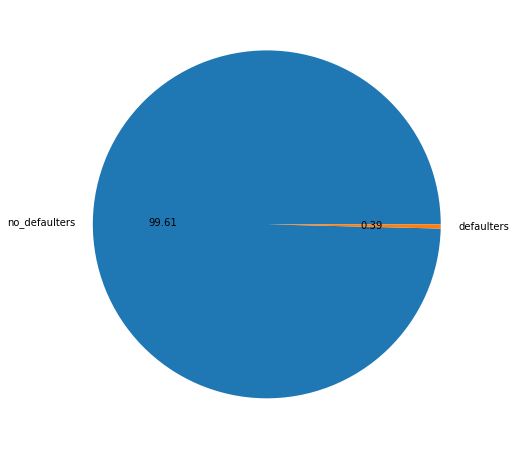

In [70]:
plt.figure(figsize=[15,8])
plt.pie(m, labels=['no_defaulters', 'defaulters'], autopct='%.2f')

inference:
df dataframe that is application data is highly imbalanced .
'defaulted population is 0.57% and non defaulted population ois 99.4%'

# bivariate analysis

# for gender vs target varibale(is_fraud)

In [71]:
df_gender=(df['gender'].value_counts()/len(df['gender']))*100
df_gender

F    54.863339
M    45.136661
Name: gender, dtype: float64

In [72]:
target0['gender'].value_counts()

F    303722
M    249852
Name: gender, dtype: int64

In [73]:
(target0.groupby("gender")["is_fraud"].count())/(len(df['is_fraud']))*100

gender
F    54.653881
M    44.960133
Name: is_fraud, dtype: float64

In [74]:
(target1.groupby("gender")["is_fraud"].count())/(len(df['is_fraud']))*100

gender
F    0.209458
M    0.176528
Name: is_fraud, dtype: float64

In [75]:
plt.rcParams['figure.figsize']=(15,5)

Text(0, 0.5, 'Fraud transactions')

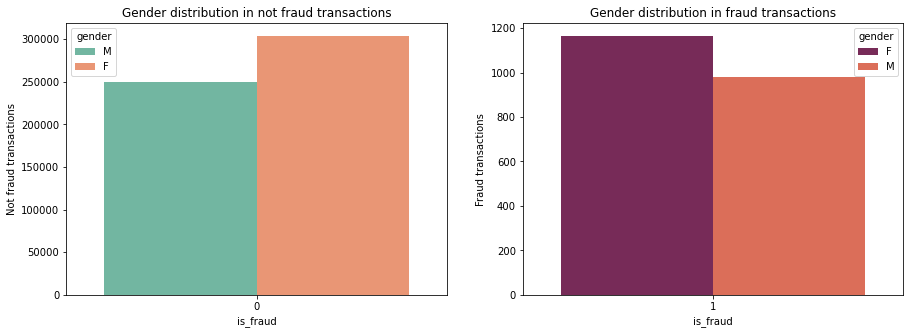

In [76]:
plt.subplot(121)
sns.countplot(x='is_fraud',hue='gender',data=target0,palette='Set2')
plt.title('Gender distribution in not fraud transactions')
plt.ylabel('Not fraud transactions')
plt.subplot(122)
sns.countplot(x='is_fraud',hue='gender',data=target1,palette='rocket')
plt.title('Gender distribution in fraud transactions')
plt.ylabel('Fraud transactions')

*it seems like female clients done more transaction than male customers
*54.45% female clients are non defaulters while 44.96% male clients are non defaulters
*0.28% female clients are defaulters and 0.29% male clients are defaulters

# Age vs target variable(is_fraud)

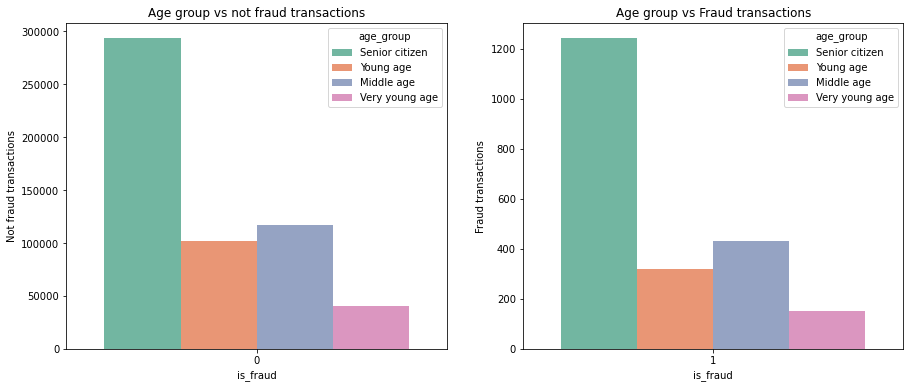

In [77]:
plt.figure(figsize=(15,6))
plt.subplot(121)
sns.countplot(x='is_fraud',hue='age_group',data=target0,palette='Set2')
plt.title('Age group vs not fraud transactions')
plt.ylabel('Not fraud transactions')
plt.subplot(122)
sns.countplot(x='is_fraud',hue='age_group',data=target1,palette='Set2')
plt.title('Age group vs Fraud transactions')
plt.ylabel('Fraud transactions')
plt.show()

Insights
*senior citizen above 60 are higher than any other in case of defaulters as well as non defaulters
*also senior citizens age group facing paying difficulties are the most
*while middle age group and very young age group facing less difficulties in paying

# Job vs target variable(is_fraud)

In [78]:
df1=target0.job.value_counts()
df1.head(10)

Film/video editor             4111
Exhibition designer           3968
Surveyor, land/geomatics      3756
Naval architect               3737
Designer, ceramics/pottery    3452
Materials engineer            3441
Environmental consultant      3412
Financial adviser             3285
IT trainer                    3256
Systems developer             3233
Name: job, dtype: int64

<AxesSubplot:>

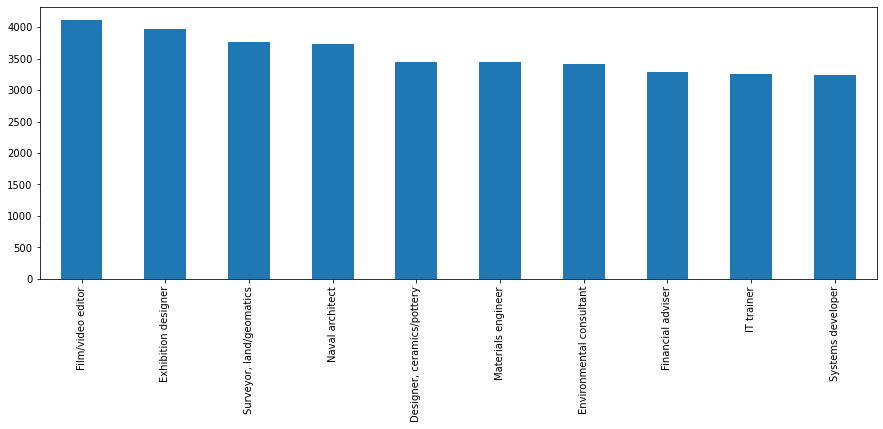

In [79]:
df1.head(10).plot(kind='bar')

#inference
1.jobs such as film editor , agriculture consultant, financial trader are quitely the non defaulters in credit card transaction

<AxesSubplot:>

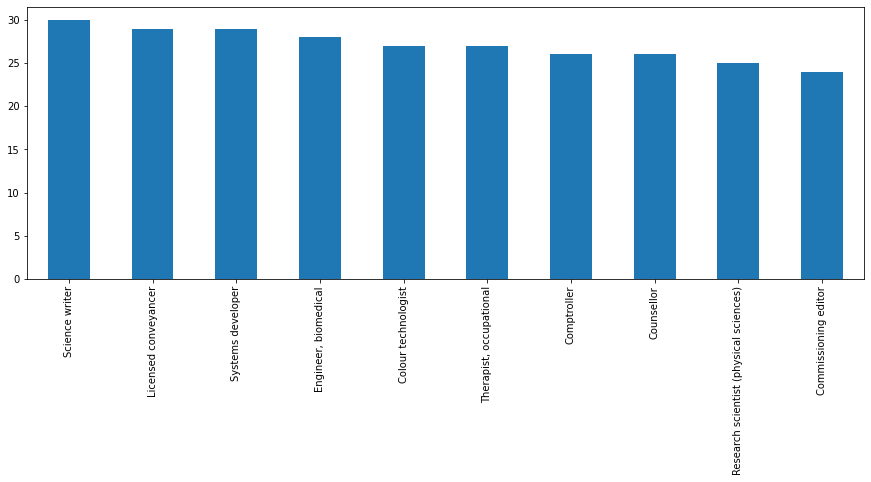

In [80]:
target1.job.value_counts().head(10).plot(kind='bar')

# inference
1.jobs such as materials engineer , podiatrist, energy engineer are quitely the defaulters in credit card transaction

# merchant vs target variable(is_fraud)

In [81]:
df_category=pd.crosstab(df['category'],df['is_fraud'])

In [82]:
df_c=df_category.reset_index()

In [83]:
df_c.rename(columns={'is_fraud':'index',0:'not_fraud',1:'fraud'},inplace=True)

In [84]:
df_c=df_c.sort_values('fraud',ascending=False)
df_c

is_fraud,category,not_fraud,fraud
11,shopping_net,41273,506
4,grocery_pos,52068,485
8,misc_net,27100,267
12,shopping_pos,49578,213
2,gas_transport,56216,154
9,misc_pos,34502,72
10,personal_care,39257,70
6,home,52278,67
7,kids_pets,48627,65
0,entertainment,40045,59


<AxesSubplot:xlabel='category', ylabel='fraud'>

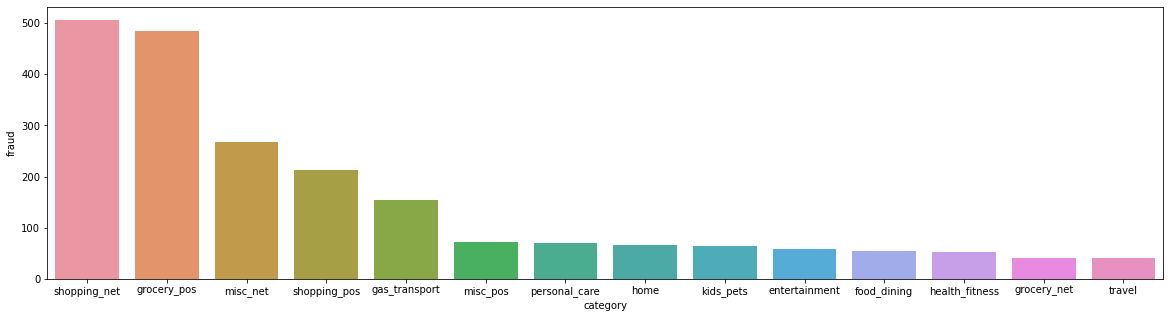

In [85]:
plt.figure(figsize=(20,5))
sns.barplot(y='fraud', x='category', data=df_c)

<AxesSubplot:xlabel='category', ylabel='not_fraud'>

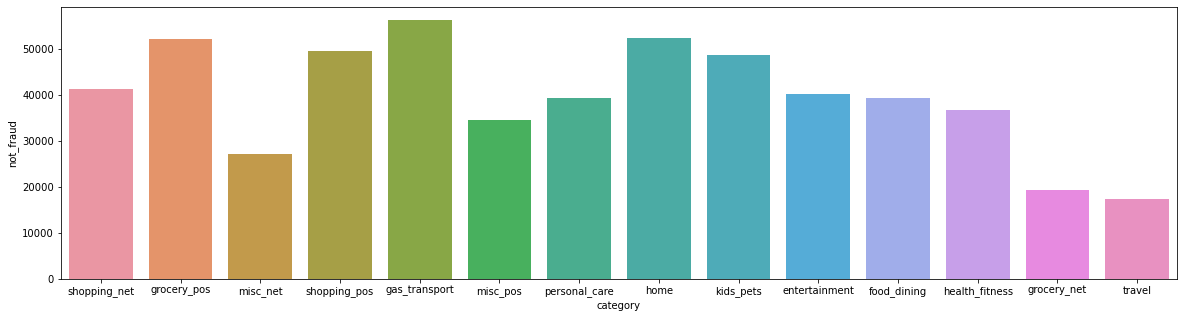

In [86]:
plt.figure(figsize=(20,5))
sns.barplot(y='not_fraud', x='category', data=df_c)

# insights 
*merchant categories such as gas_transport,home,grocery_pos, shopping_pos has high non fraud transactions
*merchant categories such as grocery_pos,shopping_net,misc_net, shopping_pos has fraud transactions

# cities of credit card holder vs target variable(is_fraud)

In [87]:
df['city'].value_counts().head(10)

Birmingham     2423
Meridian       2229
Phoenix        2222
Utica          2204
San Antonio    2182
Warren         1985
Cleveland      1968
Conway         1961
Thomas         1937
Fulton         1864
Name: city, dtype: int64

In [88]:
df_city=pd.crosstab(df['city'],df['is_fraud'])

In [89]:
df_city.reset_index(inplace=True)

In [90]:
df_city.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)

In [91]:
df_city=df_city.sort_values('fraud',ascending=False)

In [92]:
df_city.head(10)

is_fraud,city,not_fraud,fraud
111,Camden,1116,27
71,Birmingham,2398,25
108,Burrton,484,19
139,Clarks Mills,1456,18
130,Chatham,226,16
365,Jay,226,16
646,Reynolds,456,16
85,Bradley,1247,16
417,Leonard,1079,15
507,Mound City,873,15


<AxesSubplot:xlabel='city', ylabel='fraud'>

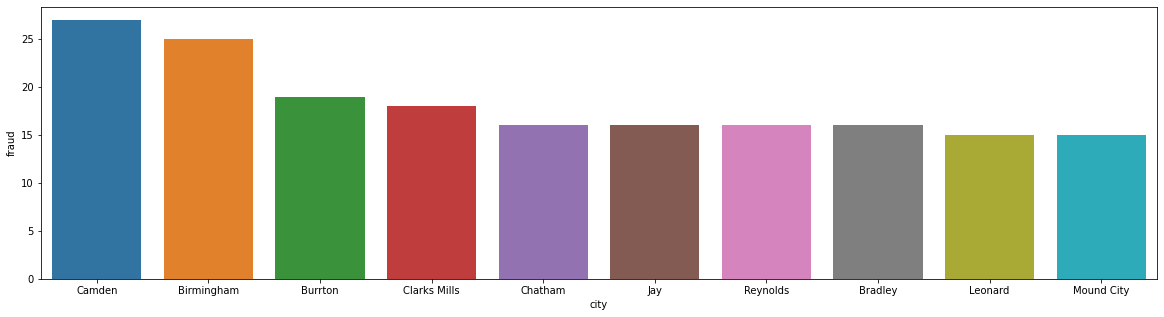

In [93]:
plt.figure(figsize=(20,5))
sns.barplot(y='fraud', x='city', data=df_city.head(10))

<AxesSubplot:xlabel='city', ylabel='not_fraud'>

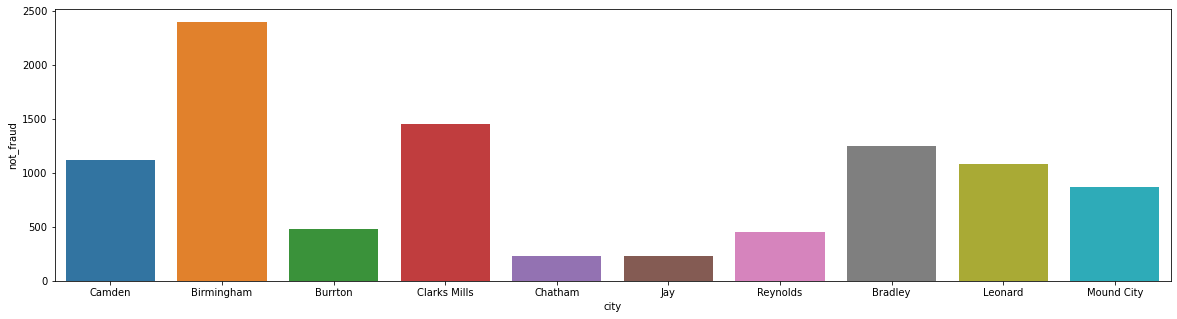

In [94]:
plt.figure(figsize=(20,5))
sns.barplot(y='not_fraud', x='city', data=df_city.head(10))

# insights:
1.we can clearly see that san Antonio city has the highest non fraud transaction where as huston city has the highest fraud transaction

# top 10 merchants vs fraud transactions and not fraud transactions

In [95]:
target0.merchant.value_counts()

fraud_Kilback LLC                        1844
fraud_Cormier LLC                        1592
fraud_Schumm PLC                         1551
fraud_Dickinson Ltd                      1518
fraud_Kuhn LLC                           1510
                                         ... 
fraud_Treutel-King                        323
fraud_Satterfield-Lowe                    318
fraud_Kessler Group                       318
fraud_Jerde-Hermann                       311
fraud_Ritchie, Bradtke and Stiedemann     304
Name: merchant, Length: 693, dtype: int64

<AxesSubplot:>

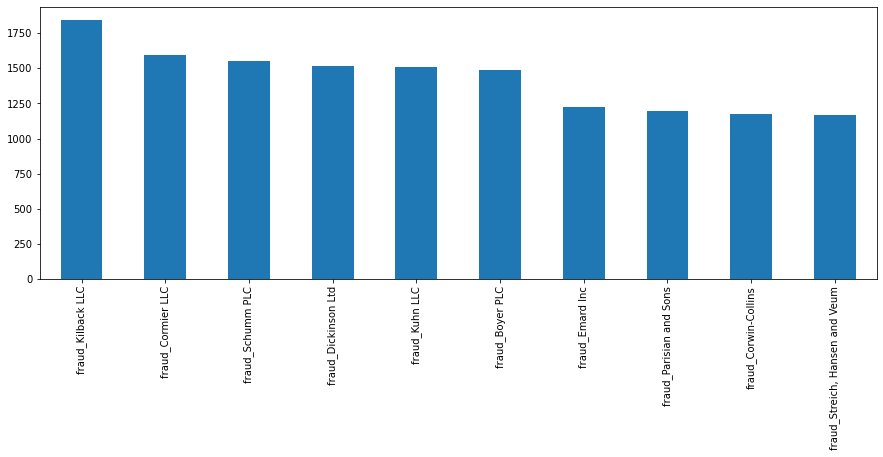

In [96]:
target0.merchant.value_counts().head(10).plot(kind='bar')

<AxesSubplot:>

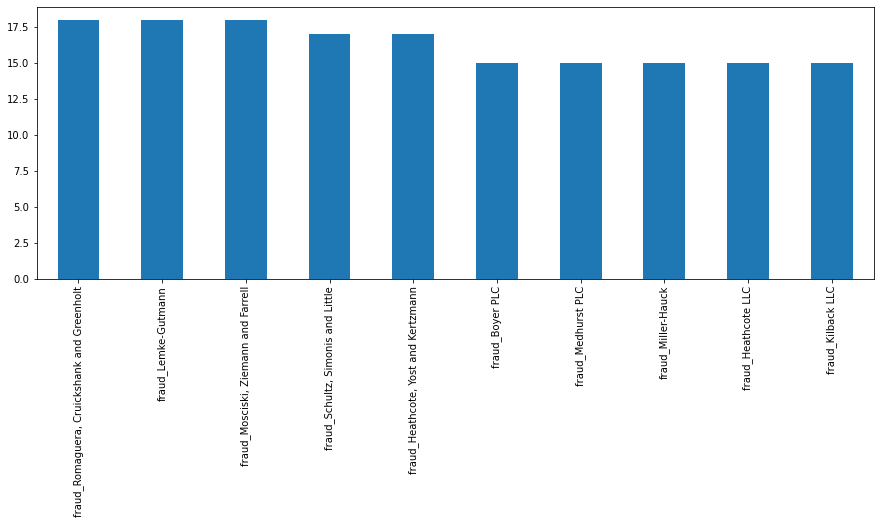

In [97]:
target1.merchant.value_counts().head(10).plot(kind='bar')

* Insights:-
*merchants like kilback llc, schumm plc , cormier llc have high non fraud transcations 
*mercahnts like rau and sons , kozey boehm , cormier llc have high fraud transactions 

# top 10 states vs fraud transactions and not fraud transactions

<AxesSubplot:>

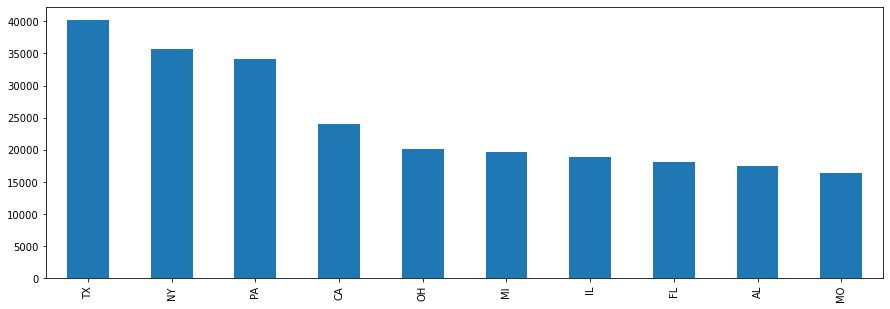

In [98]:
target0.state.value_counts().head(10).plot(kind='bar')

<AxesSubplot:>

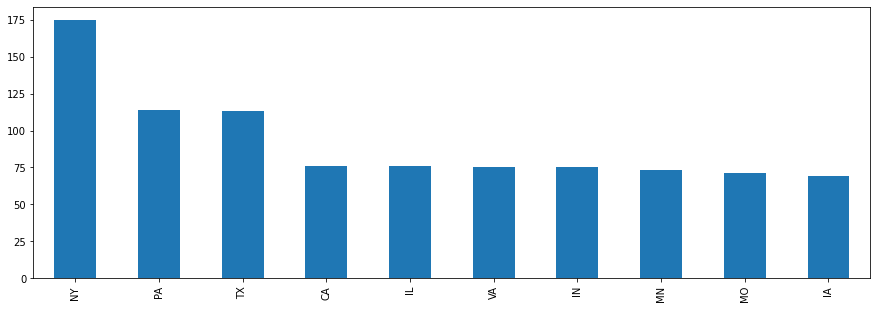

In [99]:
target1.state.value_counts().head(10).plot(kind='bar')

*Insights:-
*state tx,ny,pa has high fraud transactions as well as high non fraud transactions 

# amt vs non fraud transaction distribution and amt vs fraud transaction distribution

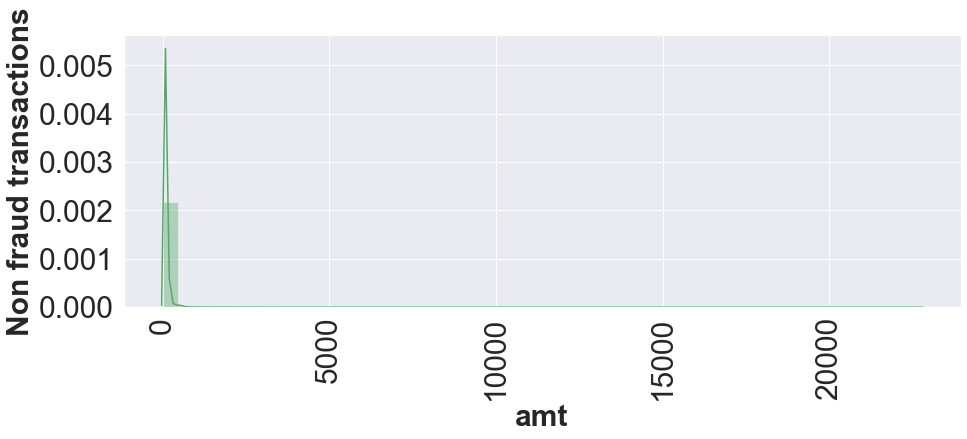

In [100]:
sns.set(style="darkgrid")                                   
sns.distplot(target0['amt'], color="g" )
plt.yscale('linear') 
plt.xlabel('amt', fontsize= 30, fontweight="bold")
plt.ylabel('Non fraud transactions', fontsize= 30, fontweight="bold")                    #Target 0
plt.xticks(rotation=90, fontsize=30)
plt.yticks(rotation=360, fontsize=30)
plt.show()

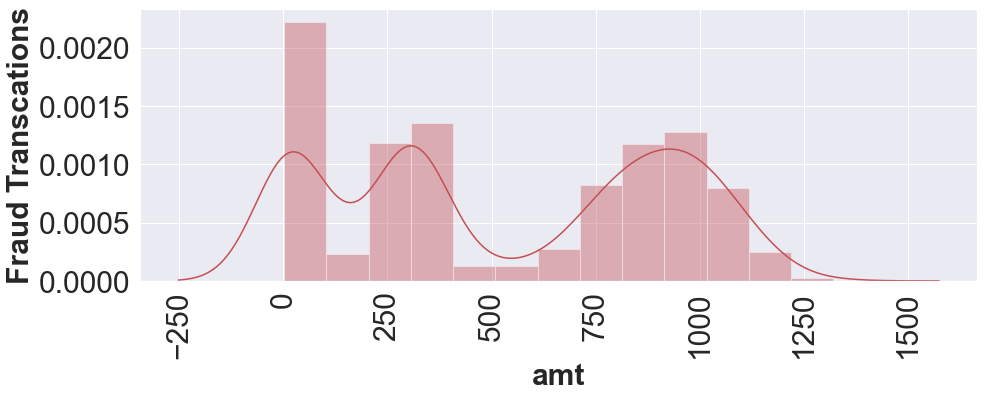

In [101]:
sns.distplot(target1['amt'], color="r")
plt.yscale('linear')    
plt.xlabel('amt', fontsize= 30, fontweight="bold")
plt.ylabel('Fraud Transcations', fontsize= 30, fontweight="bold")                       # Target 1
plt.xticks(rotation=90, fontsize=30)
plt.yticks(rotation=360, fontsize=30)
plt.show()

In [102]:
target0['amt'].skew() #highly positive skewed  

40.19626066573016

In [103]:
target1['amt'].skew() #highly positive skewed  

0.03796115306810483

Insights:-
Dist. plot highlights the curve shape which is wider for Target 1 in comparison to Target 0 which is narrower with well-defined edges.

In [104]:
target0['week_day'].value_counts()

Monday       114834
Tuesday      109782
Sunday        92724
Friday        62509
Saturday      62004
Thursday      59147
Wednesday     52574
Name: week_day, dtype: int64

<AxesSubplot:>

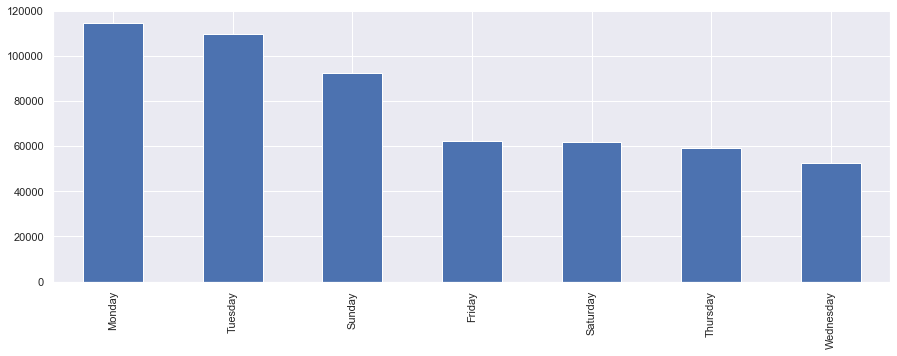

In [105]:
target0['week_day'].value_counts().plot(kind='bar')

In [106]:
target1['week_day'].value_counts()

Sunday       374
Tuesday      331
Thursday     309
Monday       302
Friday       297
Wednesday    266
Saturday     266
Name: week_day, dtype: int64

<AxesSubplot:>

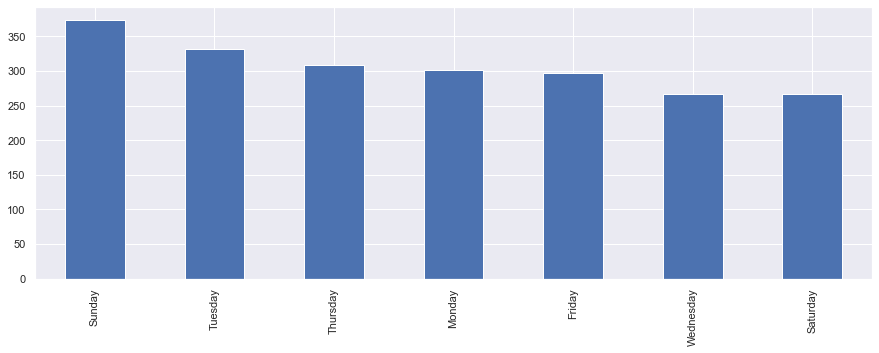

In [107]:
target1['week_day'].value_counts().plot(kind='bar')

In [108]:
target0['month_name'].value_counts().sort_values(ascending=False)

December     139280
August        88344
July          85527
November      72341
September     69193
October       68964
June          29925
Name: month_name, dtype: int64

<AxesSubplot:>

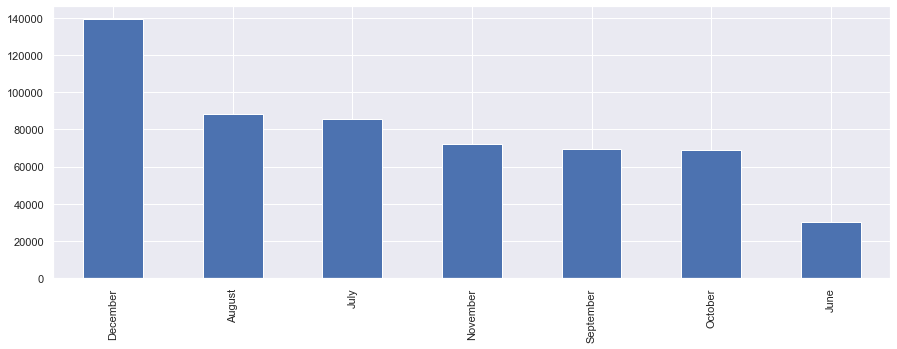

In [109]:
target0['month_name'].value_counts().sort_values(ascending=False).plot(kind='bar')

In [110]:
target0['month_name'].value_counts().sort_values(ascending=False)

December     139280
August        88344
July          85527
November      72341
September     69193
October       68964
June          29925
Name: month_name, dtype: int64

<AxesSubplot:>

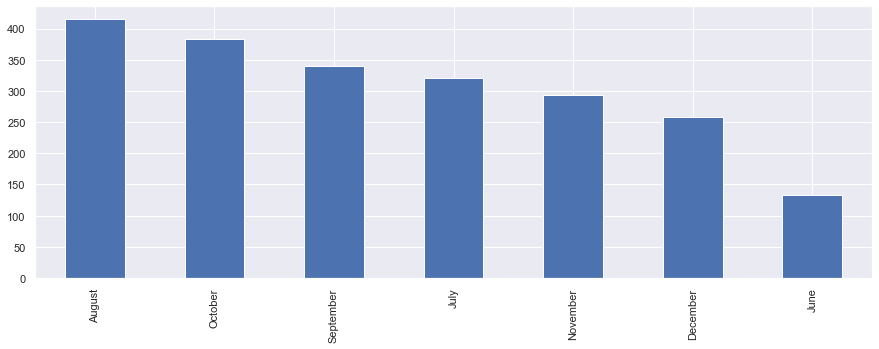

In [111]:
target1['month_name'].value_counts().sort_values(ascending=False).plot(kind='bar')

# Multivariate Analysis

# merchant vs amount transaction vs target variable

In [112]:
df_merch_amt=df.pivot_table(index='merchant',columns='is_fraud',values='amt',aggfunc='sum')

In [113]:
df_merch_amt.reset_index(inplace=True)

In [114]:
df_merch_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)

In [115]:
df_merch_amt=df_merch_amt.head(10)
df_merch_amt

is_fraud,merchant,not_fraud,fraud
0,fraud_Abbott-Rogahn,52667.62,489.67
1,fraud_Abbott-Steuber,39196.59,39.43
2,fraud_Abernathy and Sons,38595.78,NaN
3,fraud_Abshire PLC,52737.75,NaN
4,"fraud_Adams, Kovacek and Kuhlman",22605.34,15.83
5,fraud_Adams-Barrows,41659.46,58.34
6,"fraud_Altenwerth, Cartwright and Koss",55570.22,13746.82
7,fraud_Altenwerth-Kilback,62794.52,NaN
8,fraud_Ankunding LLC,61989.69,5130.66
9,fraud_Ankunding-Carroll,52156.14,8.85


<AxesSubplot:xlabel='merchant', ylabel='not_fraud'>

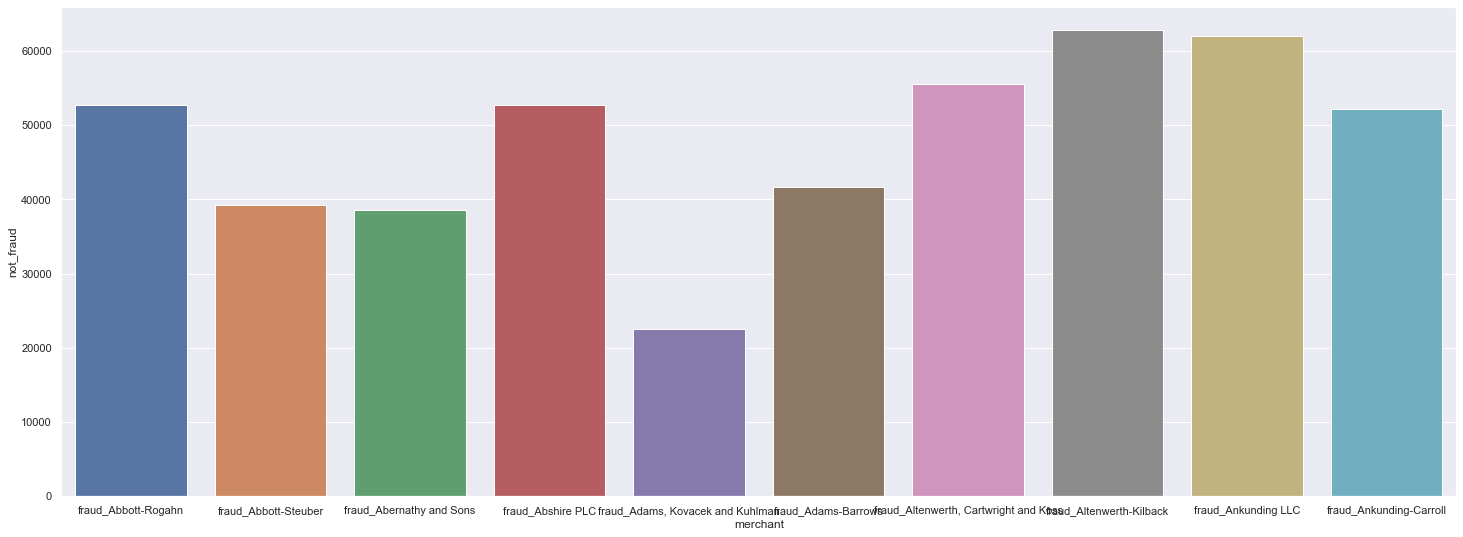

In [116]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='merchant', data=df_merch_amt)

<AxesSubplot:xlabel='merchant', ylabel='fraud'>

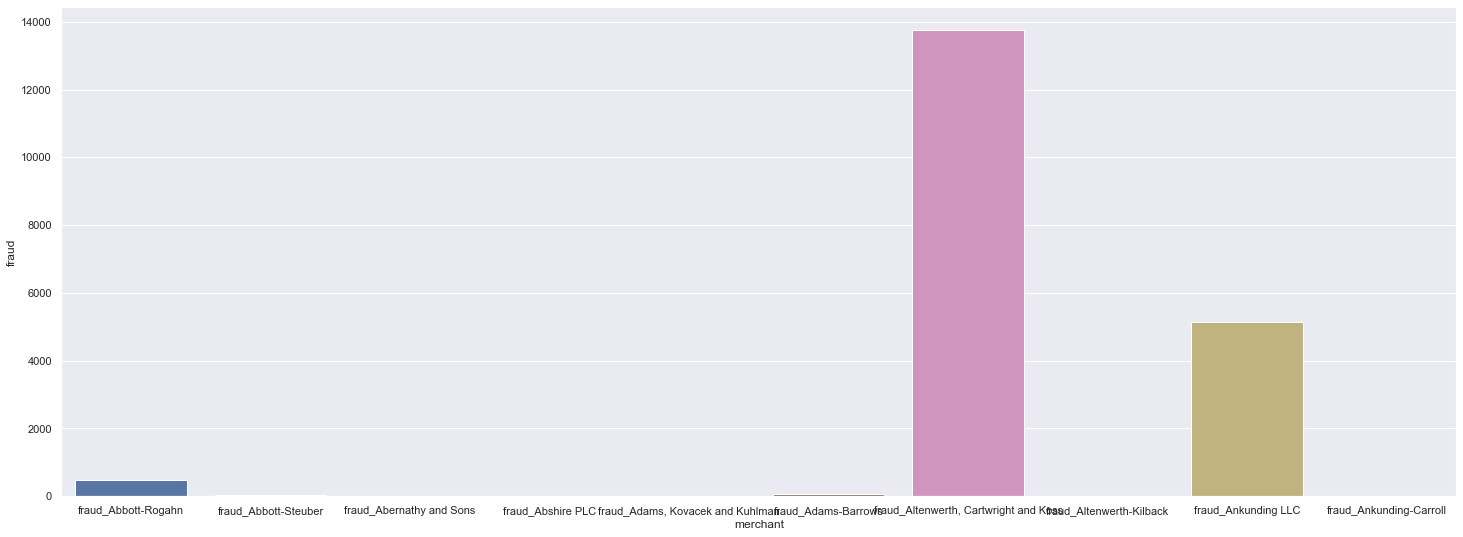

In [117]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='merchant', data=df_merch_amt)

# job vs amount transaction vs target variable

In [118]:
df_job_amt=df.pivot_table(index='job',columns='is_fraud',values='amt',aggfunc='sum')
df_job_amt.reset_index(inplace=True)
df_job_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)
df_job_amt=df_job_amt.sort_values('fraud',ascending=False).head(10)
df_job_amt

is_fraud,job,not_fraud,fraud
90,Commissioning editor,40672.45,19305.04
260,Licensed conveyancer,76807.46,16757.18
455,"Therapist, occupational",131247.25,16244.87
430,Systems developer,216534.17,14925.96
149,"Engineer, biomedical",154045.17,14868.87
67,Chemical engineer,161015.21,14553.84
393,Science writer,131634.29,14141.66
97,Comptroller,160666.56,13882.97
369,Quantity surveyor,146557.72,13810.39
87,Colour technologist,91293.95,12626.03


<AxesSubplot:xlabel='job', ylabel='not_fraud'>

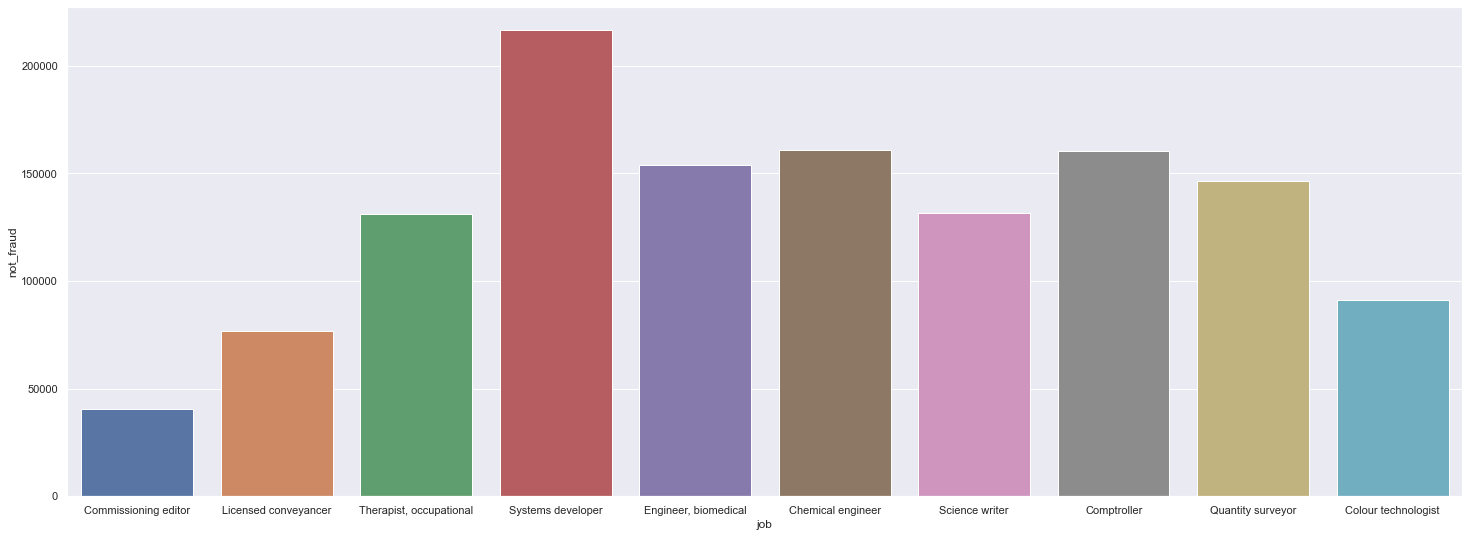

In [119]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='job', data=df_job_amt)

<AxesSubplot:xlabel='job', ylabel='fraud'>

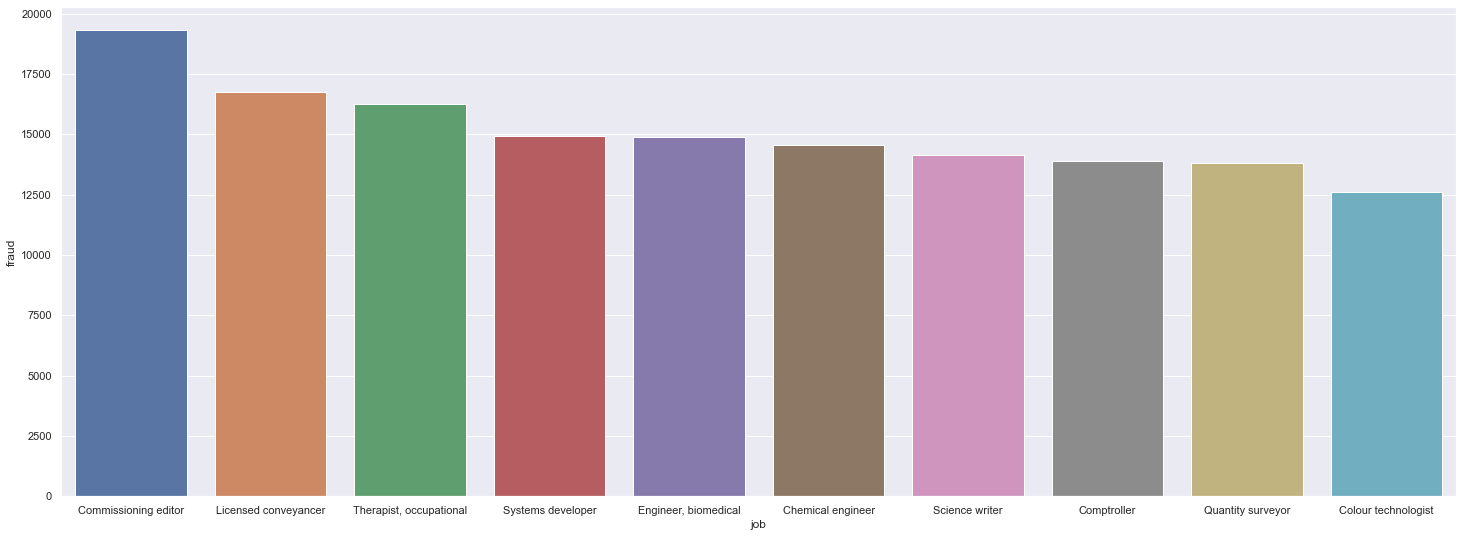

In [120]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='job', data=df_job_amt)

# month vs amount transaction vs target variable

In [121]:
df['month_name'].value_counts()

December     139538
August        88759
July          85848
November      72635
September     69533
October       69348
June          30058
Name: month_name, dtype: int64

In [122]:
df_month_amt=df.pivot_table(index='month_name',columns='is_fraud',values='amt',aggfunc='sum')
df_month_amt.reset_index(inplace=True)
df_month_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)
df_month_amt=df_month_amt.head(12)
df_month_amt

is_fraud,month_name,not_fraud,fraud
0,August,5924692.74,208785.43
1,December,9461994.37,141138.68
2,July,5779543.25,158669.49
3,June,2006263.42,73274.93
4,November,4875405.54,153182.19
5,October,4673380.02,195572.97
6,September,4708299.09,202700.99


<AxesSubplot:xlabel='month_name', ylabel='not_fraud'>

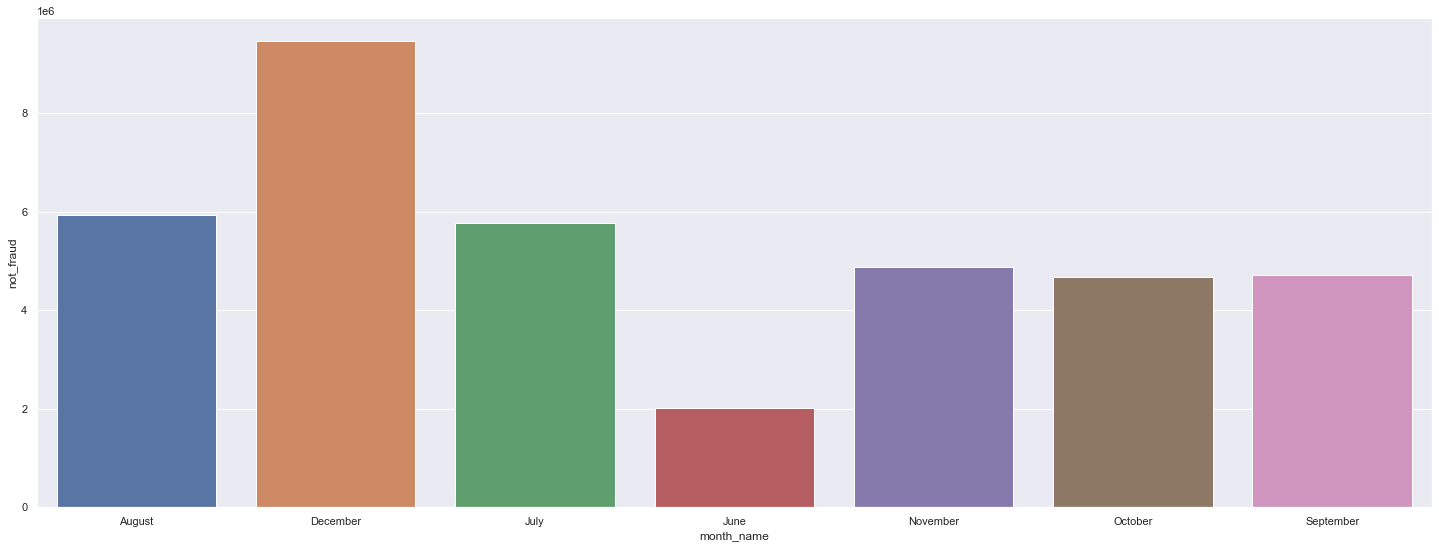

In [123]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='month_name', data=df_month_amt)

<AxesSubplot:xlabel='month_name', ylabel='fraud'>

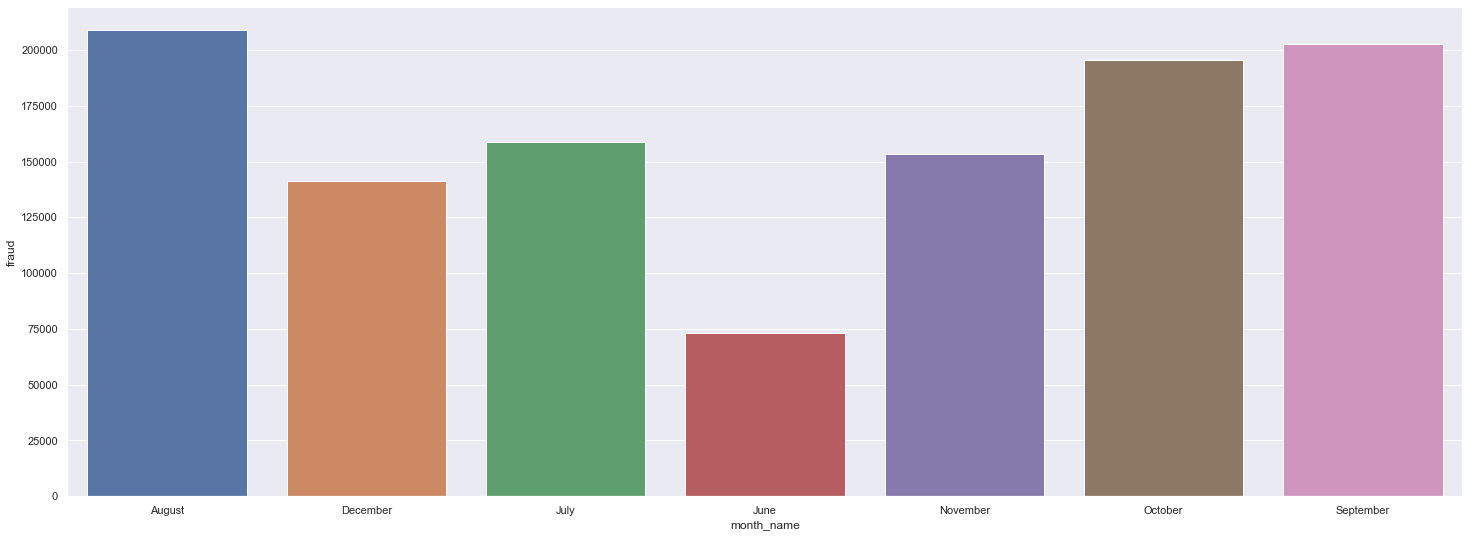

In [124]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='month_name', data=df_month_amt)

# Merchant Category vs amt transaction vs target variable 

In [125]:
df_mercat_amt=df.pivot_table(index='category',columns='is_fraud',values='amt',aggfunc='sum')
df_mercat_amt.reset_index(inplace=True)
df_mercat_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)
df_mercat_amt=df_mercat_amt.sort_values('fraud',ascending=False).head(10)
df_mercat_amt

is_fraud,category,not_fraud,fraud
11,shopping_net,2984656.06,503123.93
8,misc_net,1936309.73,214742.95
12,shopping_pos,3638171.36,188887.25
4,grocery_pos,5938254.87,151866.72
0,entertainment,2535971.85,30076.17
6,home,3018509.59,17260.30
9,misc_pos,2135965.15,13923.82
1,food_dining,1987340.54,6607.54
2,gas_transport,3581987.14,1848.42
10,personal_care,1895045.56,1814.44


<AxesSubplot:xlabel='category', ylabel='not_fraud'>

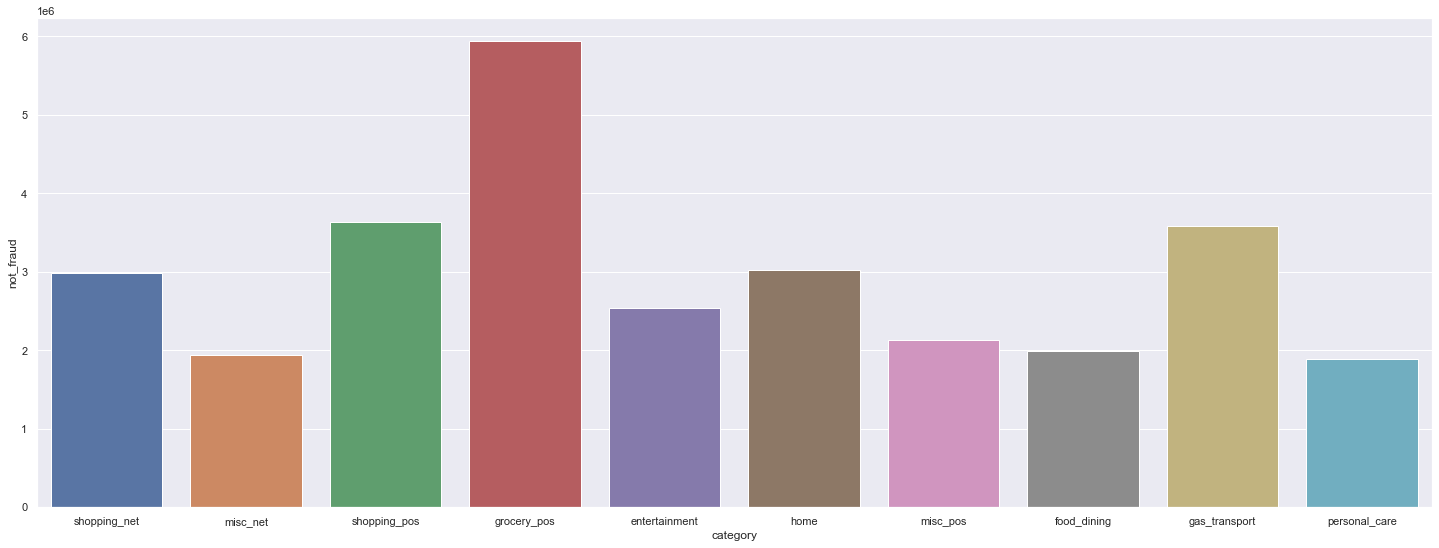

In [126]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='category', data=df_mercat_amt)

<AxesSubplot:xlabel='category', ylabel='fraud'>

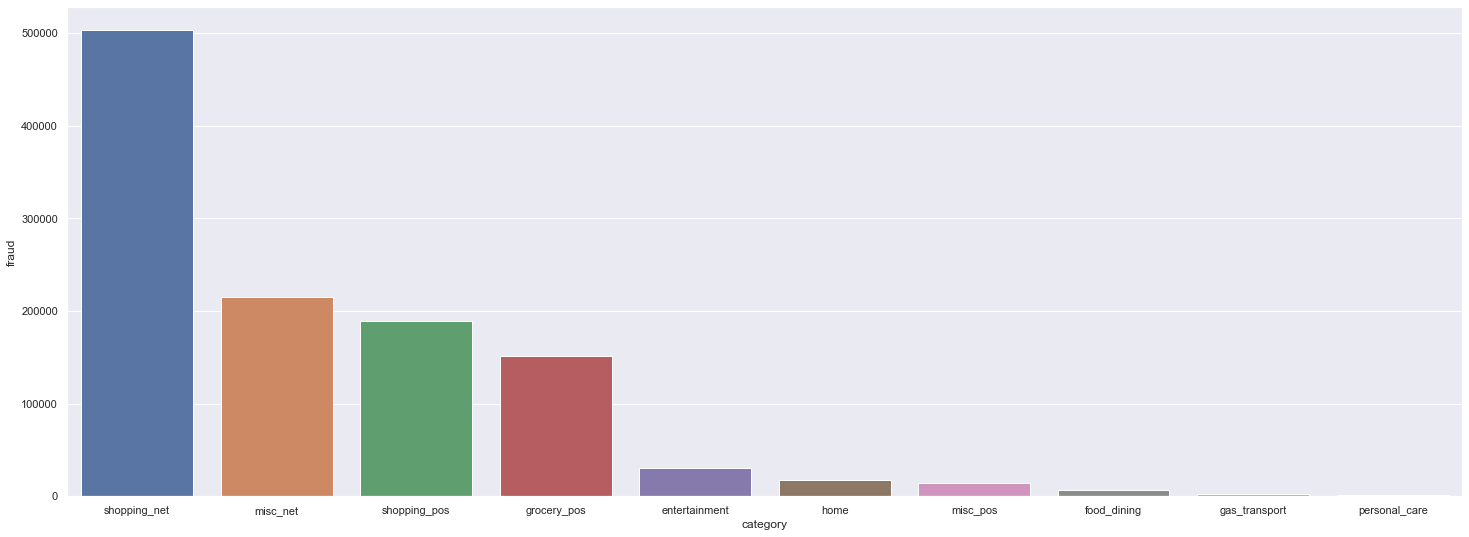

In [127]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='category', data=df_mercat_amt)

# state vs amt transaction vs target variable 

In [128]:
df_state_amt=df.pivot_table(index='state',columns='is_fraud',values='amt',aggfunc='sum')
df_state_amt.reset_index(inplace=True)
df_state_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)
df_state_amt=df_state_amt.sort_values('fraud',ascending=False).head(10)
df_state_amt

is_fraud,state,not_fraud,fraud
33,NY,2429994.97,99746.68
37,PA,2371811.70,62807.61
42,TX,2704186.84,52310.40
16,KY,814378.75,42175.29
44,VA,826403.39,41752.78
47,WI,833723.09,40039.48
23,MO,1062070.80,38223.18
21,MI,1362223.48,37753.48
1,AL,1091448.30,36474.51
22,MN,922046.87,36080.51


<AxesSubplot:xlabel='state', ylabel='not_fraud'>

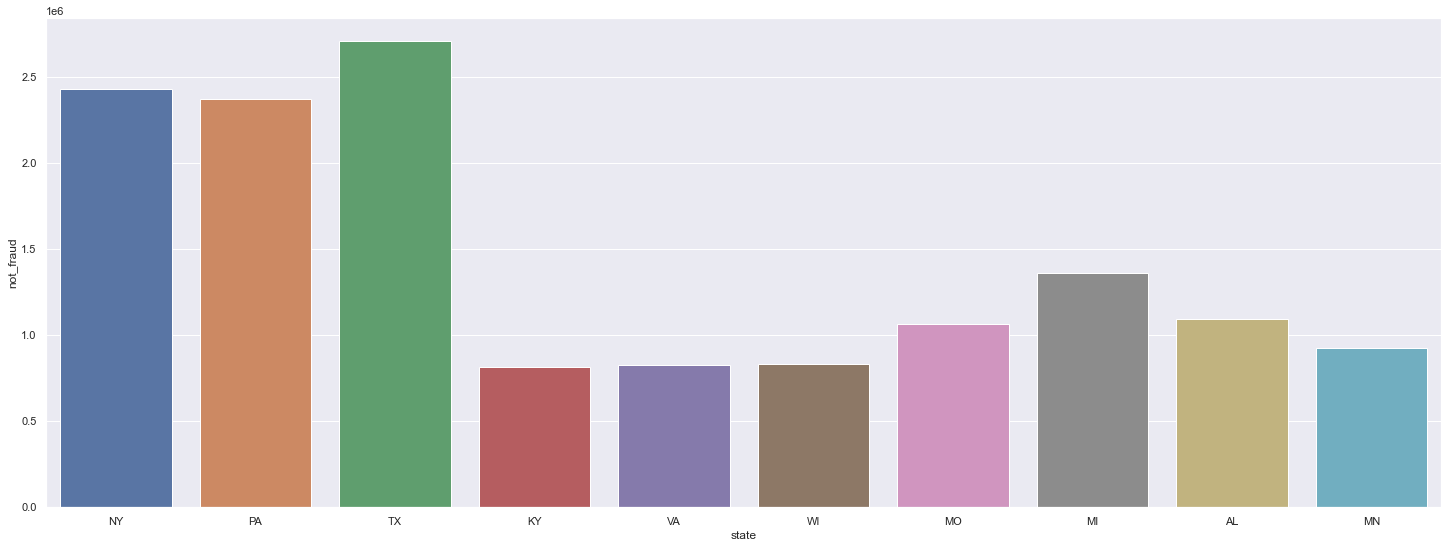

In [129]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='state', data=df_state_amt)

<AxesSubplot:xlabel='state', ylabel='fraud'>

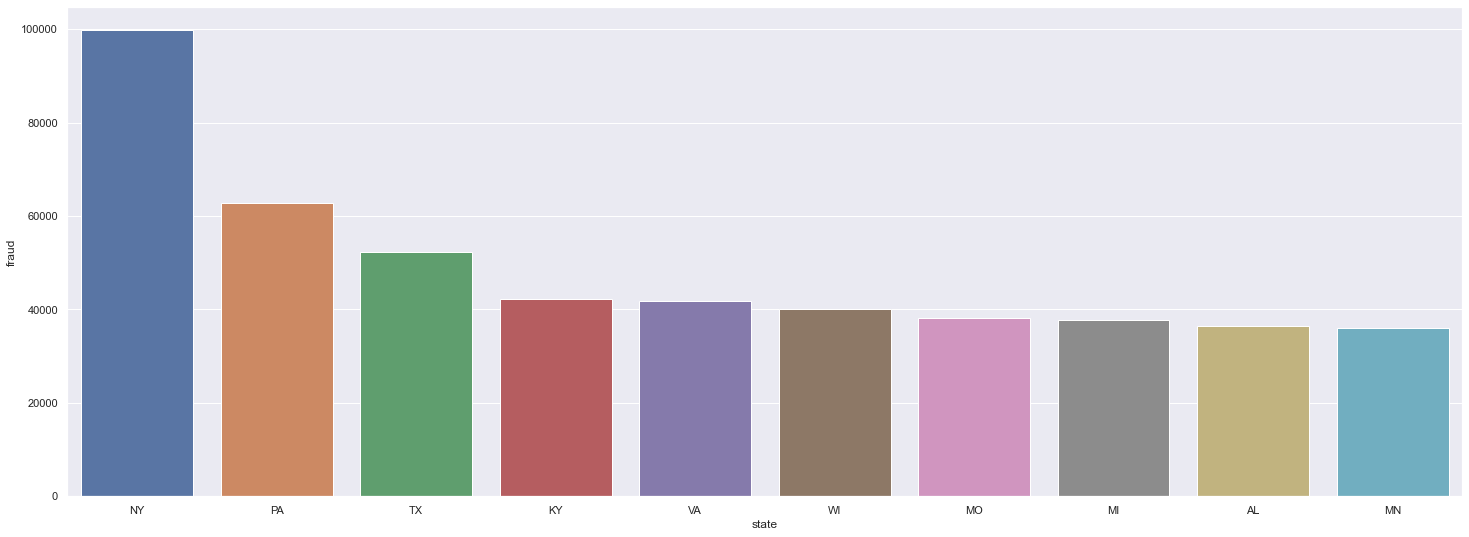

In [130]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='state', data=df_state_amt)

# city vs amt transaction vs target variable 

In [131]:
df_city_amt=df.pivot_table(index='city',columns='is_fraud',values='amt',aggfunc='sum')
df_city_amt.reset_index(inplace=True)
df_city_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)
df_city_amt=df_city_amt.sort_values('fraud',ascending=False).head(10)
df_city_amt

is_fraud,city,not_fraud,fraud
71,Birmingham,137037.58,14861.14
111,Camden,71687.13,12626.03
108,Burrton,35483.51,12002.06
168,Craig,NaN,11641.22
139,Clarks Mills,104071.66,10956.00
391,Kirkwood,NaN,9874.94
232,Elk Rapids,20203.19,9793.38
616,Port Ewen,40320.79,9529.37
136,Cisco,50754.02,8893.06
117,Carlotta,50156.57,8601.33


<AxesSubplot:xlabel='city', ylabel='not_fraud'>

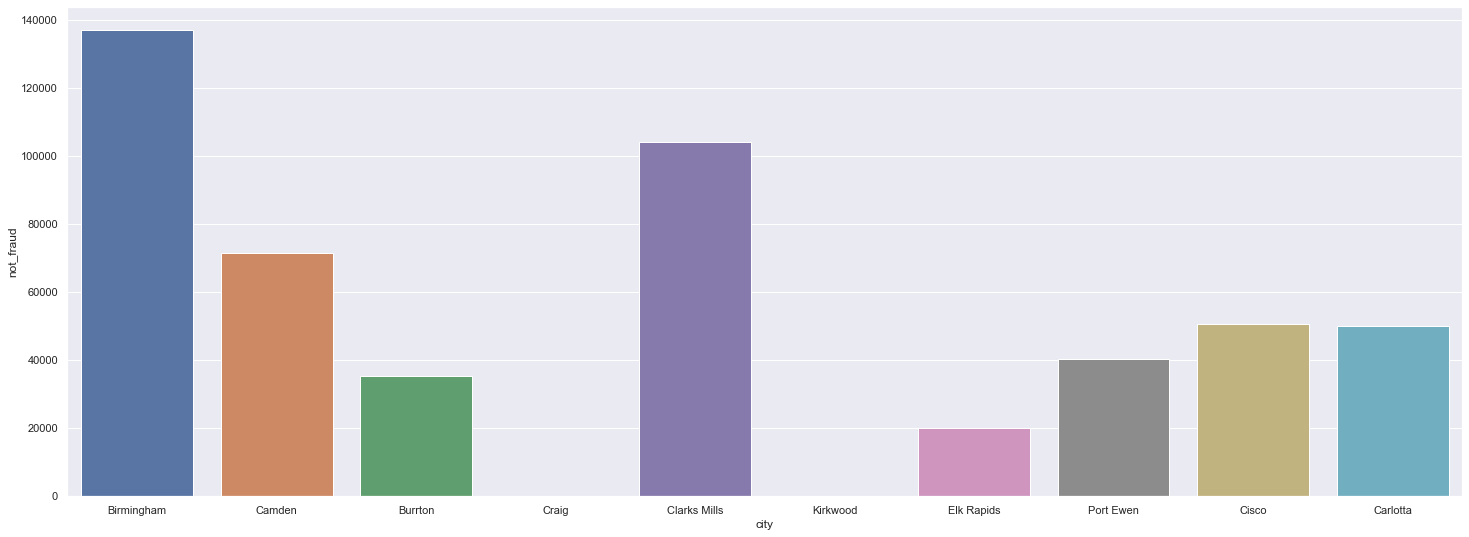

In [132]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='city', data=df_city_amt)

<AxesSubplot:xlabel='city', ylabel='fraud'>

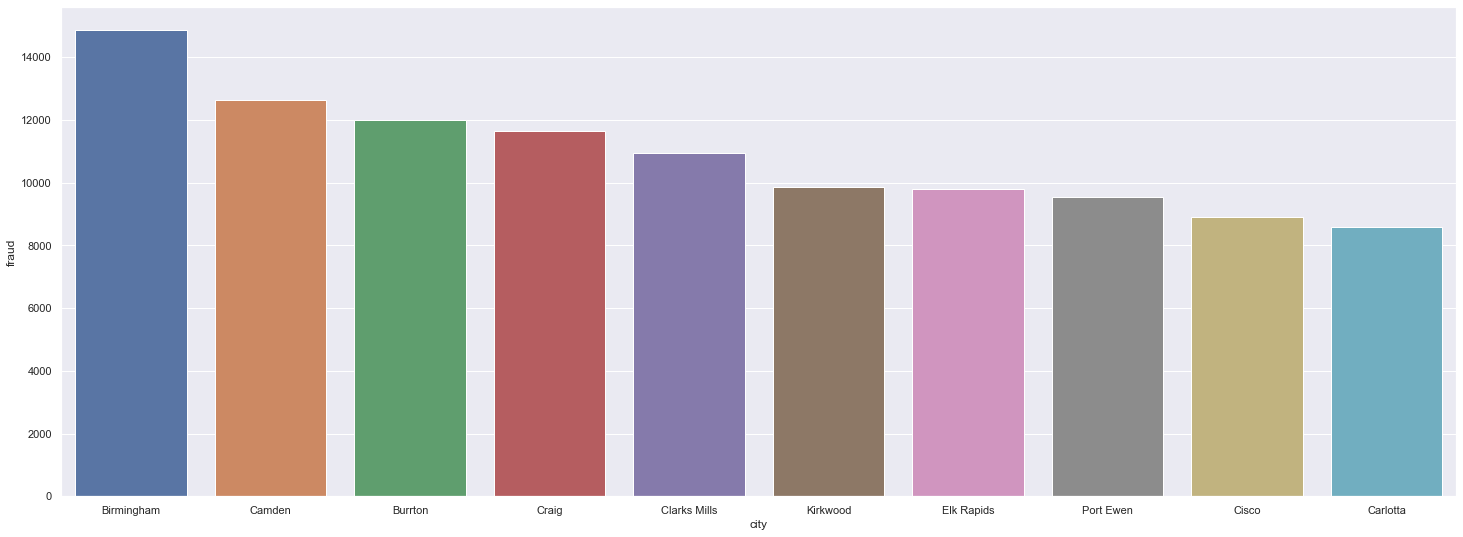

In [133]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='city', data=df_city_amt)

# Gender vs amt transaction amount vs target variable

In [134]:
df_gender_amt=df.pivot_table(index='gender',columns='is_fraud',values='amt',aggfunc='sum')
df_gender_amt.reset_index(inplace=True)
df_gender_amt.rename(columns={0:'not_fraud',1:'fraud'},inplace=True)
df_gender_amt=df_gender_amt.sort_values('fraud',ascending=False).head(10)
df_gender_amt

is_fraud,gender,not_fraud,fraud
1,M,16831332.12,575865.44
0,F,20598246.31,557459.24


<AxesSubplot:xlabel='gender', ylabel='not_fraud'>

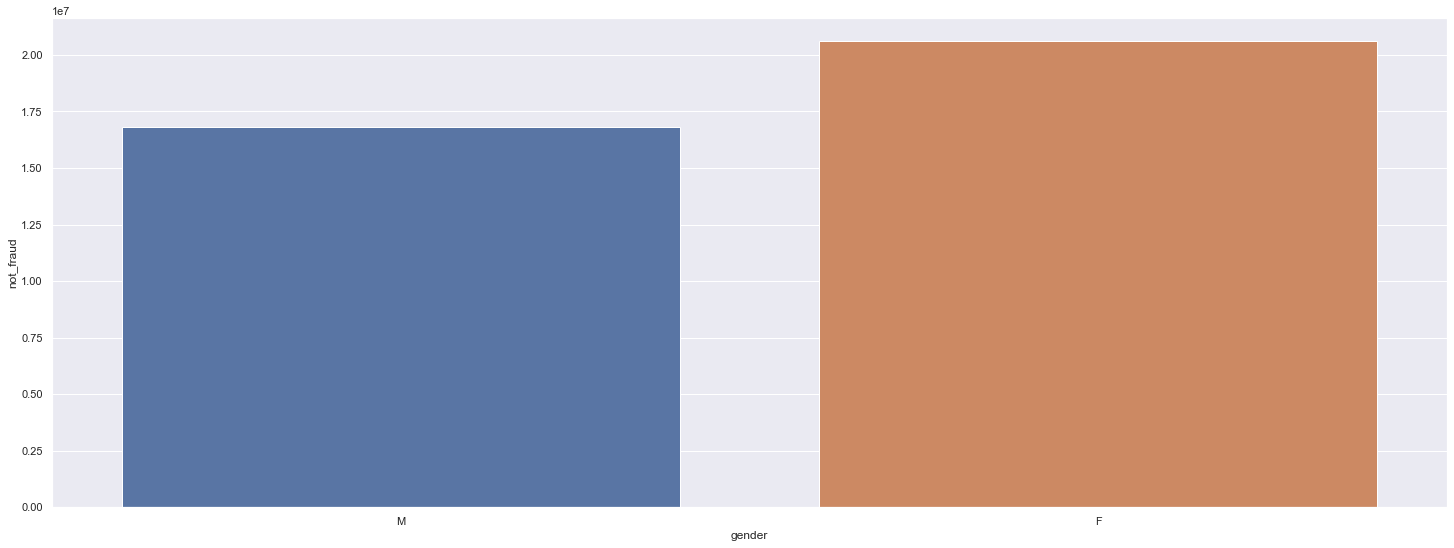

In [135]:
plt.figure(figsize=(25,9))
sns.barplot(y='not_fraud', x='gender', data=df_gender_amt)

<AxesSubplot:xlabel='gender', ylabel='fraud'>

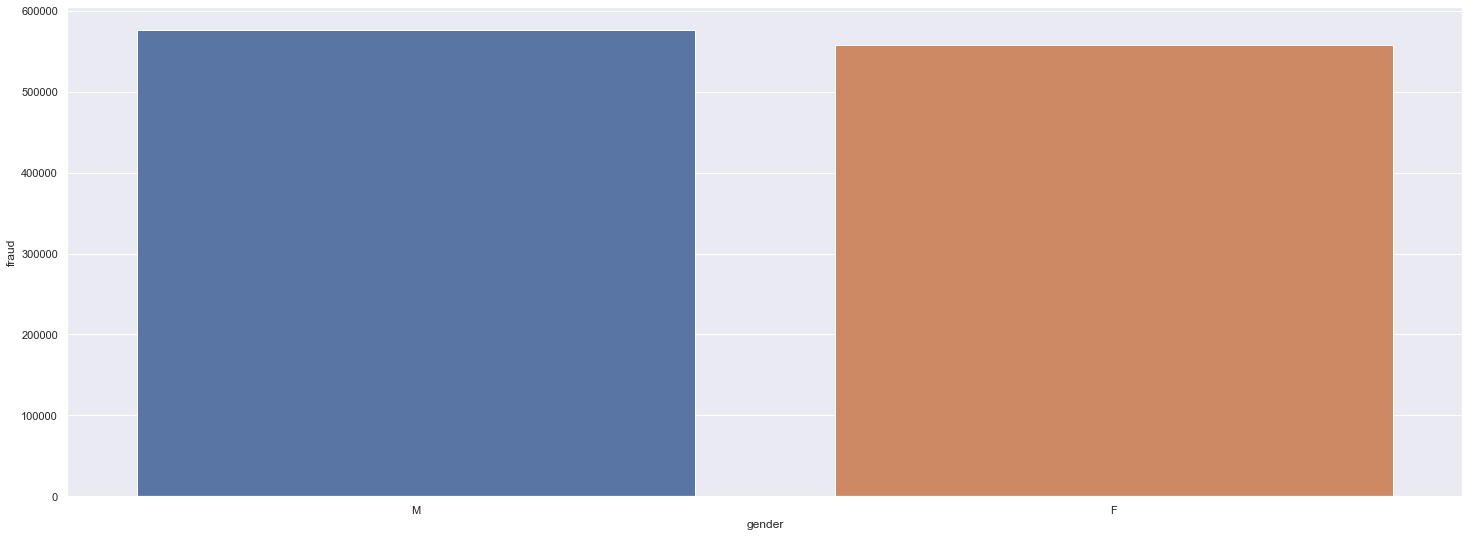

In [136]:
plt.figure(figsize=(25,9))
sns.barplot(y='fraud', x='gender', data=df_gender_amt)

# month vs amount vs target variable trend graph# month vs amount vs target variable trend graph

In [137]:
df.pivot_table(index=['year','month_name'],columns=['is_fraud'],values='amt',aggfunc='sum')

is_fraud                  0          1
year month_name                       
2020 August      5924692.74  208785.43
     December    9461994.37  141138.68
     July        5779543.25  158669.49
     June        2006263.42   73274.93
     November    4875405.54  153182.19
     October     4673380.02  195572.97
     September   4708299.09  202700.99

<AxesSubplot:xlabel='year,month_name'>

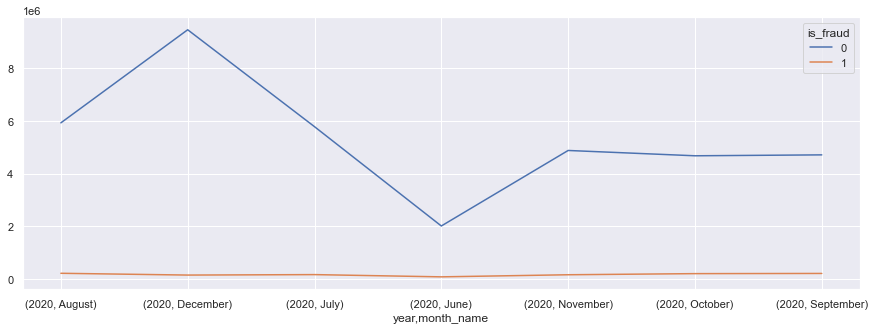

In [138]:
df.pivot_table(index=['year','month_name'],columns=['is_fraud'],values='amt',aggfunc='sum').plot(kind='line')

In [139]:
df_trend=df.pivot_table(index=['year','month_name','month'],columns=['is_fraud'],values='amt',aggfunc='sum')

In [140]:
df_trend.reset_index(inplace=True)

In [141]:
df_trend.rename(columns={0:'not_fraud transaction amount',1:'fraud transaction amount'},inplace=True)

In [142]:
df_trend

is_fraud,year,month_name,month,not_fraud transaction amount,fraud transaction amount
0,2020,August,8,5924692.74,208785.43
1,2020,December,12,9461994.37,141138.68
2,2020,July,7,5779543.25,158669.49
3,2020,June,6,2006263.42,73274.93
4,2020,November,11,4875405.54,153182.19
5,2020,October,10,4673380.02,195572.97
6,2020,September,9,4708299.09,202700.99


In [143]:
df_trend=df_trend.sort_values('month')

<AxesSubplot:xlabel='month_name', ylabel='fraud transaction amount'>

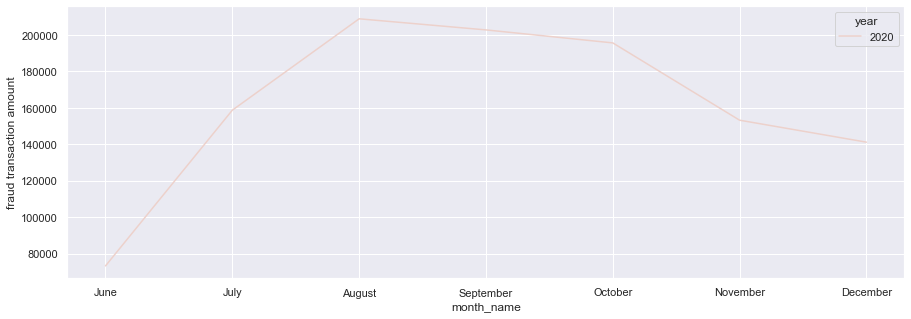

In [144]:
sns.lineplot(x='month_name', y="fraud transaction amount", hue='year', data=df_trend)

Insights:-from the dataset ,
 2019 fraud transaction amount got its peak during december month and least at june month
 2020 fraud transaction amount got its peak during may month and least during the april month 

# Dropping unrelevant columns from the dataset

In [145]:
df_new=df.drop(['first','last','street','zip','trans_num','unix_time'],axis=1)

In [146]:
df_new.head(2)

,merchant,category,amt,gender,city,state,lat,long,city_pop,job,...,week_no,day_no,min_day,hr_day,month_name,month,year,year_dayno,no_of_years,age_group
0,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,...,25,21,14,12,June,6,2020,173,54,Senior citizen
1,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",...,25,21,14,12,June,6,2020,173,32,Young age


In [147]:
df_new.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'weekday_no',
       'week_day', 'week_no', 'day_no', 'min_day', 'hr_day', 'month_name',
       'month', 'year', 'year_dayno', 'no_of_years', 'age_group'],
      dtype='object')

In [148]:
df_new.dtypes

merchant        object
category        object
amt            float64
gender          object
city            object
state           object
lat            float64
long           float64
city_pop         int64
job             object
merch_lat      float64
merch_long     float64
is_fraud         int64
weekday_no       int64
week_day        object
week_no          int64
day_no           int64
min_day          int64
hr_day           int64
month_name      object
month            int64
year             int64
year_dayno       int64
no_of_years      int64
age_group       object
dtype: object

In [149]:
df_new.shape

(555719, 25)

In [150]:
df_num=df_new.select_dtypes(include='number')
df_num.head(2)

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud,weekday_no,week_no,day_no,min_day,hr_day,month,year,year_dayno,no_of_years
0,2.86,33.9659,-80.9355,333497,33.986391,-81.200714,0,6,25,21,14,12,6,2020,173,54
1,29.84,40.3207,-110.4360,302,39.450498,-109.960431,0,6,25,21,14,12,6,2020,173,32


In [151]:
df_num.columns

Index(['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud',
       'weekday_no', 'week_no', 'day_no', 'min_day', 'hr_day', 'month', 'year',
       'year_dayno', 'no_of_years'],
      dtype='object')

In [152]:
len(df_num.columns)

16

In [153]:
df_cat=df_new.select_dtypes(include='object')
df_cat.head(2)

,merchant,category,gender,city,state,job,week_day,month_name,age_group
0,fraud_Kirlin and Sons,personal_care,M,Columbia,SC,Mechanical engineer,Sunday,June,Senior citizen
1,fraud_Sporer-Keebler,personal_care,F,Altonah,UT,"Sales professional, IT",Sunday,June,Young age


In [154]:
df_cat.columns

Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'week_day',
       'month_name', 'age_group'],
      dtype='object')

In [155]:
len(df_cat.columns)

9

In [156]:
df.weekday_no.value_counts()

0    115136
1    110113
6     93098
4     62806
5     62270
3     59456
2     52840
Name: weekday_no, dtype: int64

In [157]:
df.week_no.value_counts()

50    31929
51    31858
49    31856
52    31504
28    20146
26    20029
32    20019
27    19995
30    19918
29    19792
34    19781
31    19754
35    19599
33    19523
53    18921
36    17681
37    16268
46    16102
40    16018
38    16008
44    15993
42    15972
41    15928
39    15922
43    15888
45    15867
47    15754
48    15666
25     2028
Name: week_no, dtype: int64

In [158]:
df.day_no.value_counts()

28    22440
30    22198
29    21815
22    21619
27    21436
21    21151
7     19426
20    19285
6     19233
13    19146
14    19132
23    18877
1     18602
26    18156
24    18031
25    17833
8     17706
15    17631
10    16717
3     16429
17    16319
11    16195
4     16067
18    16016
19    15876
5     15769
12    15657
9     15387
2     15014
16    14946
31    11610
Name: day_no, dtype: int64

In [159]:
df.month.value_counts()

12    139538
8      88759
7      85848
11     72635
9      69533
10     69348
6      30058
Name: month, dtype: int64

# Hypothetical Testing

# Categorical vs Categorical(target_variable)

In [160]:
df_cat.columns

Index(['merchant', 'category', 'gender', 'city', 'state', 'job', 'week_day',
       'month_name', 'age_group'],
      dtype='object')

# Merchant vs is_fraud(target)

In [161]:
#null: merchant and is_fraud are independent
#alter:merchant and is_fraud are dependent

In [162]:
df.merchant.nunique()

693

In [163]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['merchant'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 1.8022270460261968e-205
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis 
concluding that merchant and is_fraud are dependent

# Gender vs is_fraud(target)

In [164]:
df.gender.unique()

array(['M', 'F'], dtype=object)

In [165]:
#null: gender and is_fraud are independent
#alter:gender and is_fraud are dependent

In [166]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['gender'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 0.5922844718406959
Independent (H0 holds true)


#pvalue is greater than significance level we fail to reject the null hypothesis
concluding that year and is_fraud are independent

# City vs is_fraud(target)

In [167]:
#null: gender and is_fraud are independent
#alter:gender and is_fraud are dependent

In [168]:
df.city.nunique()

849

In [169]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['city'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 0.0
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that city and is_fraud are dependent

# Category vs is_fraud(target)

In [170]:
#null: category and is_fraud are independent
#alter:category and is_fraud are dependent

In [171]:
df.category.unique()

array(['personal_care', 'health_fitness', 'misc_pos', 'travel',
       'kids_pets', 'shopping_pos', 'food_dining', 'home',
       'entertainment', 'shopping_net', 'misc_net', 'grocery_pos',
       'gas_transport', 'grocery_net'], dtype=object)

In [172]:
df.category.nunique()

14

In [173]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['category'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 0.0
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that category and is_fraud are dependent

# State vs is_fraud(target)

In [174]:
#null: state and is_fraud are independent
#alter:state and is_fraud are dependent

In [175]:
df.state.unique()

array(['SC', 'UT', 'NY', 'FL', 'MI', 'CA', 'SD', 'PA', 'TX', 'KY', 'WY',
       'AL', 'LA', 'GA', 'CO', 'OH', 'WI', 'VT', 'AR', 'NJ', 'IA', 'MD',
       'MS', 'KS', 'IL', 'MO', 'ME', 'TN', 'DC', 'AZ', 'MT', 'MN', 'OK',
       'WA', 'WV', 'NM', 'MA', 'NE', 'VA', 'ID', 'OR', 'IN', 'NC', 'NH',
       'ND', 'CT', 'NV', 'HI', 'RI', 'AK'], dtype=object)

In [176]:
df.state.nunique()

50

In [177]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['state'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 6.739748689620309e-66
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that state and is_fraud are dependent

# Job vs is_fraud(target)

In [178]:
#null: job and is_fraud are independent
#alter:job and is_fraud are dependent

In [179]:
df.job.nunique()

478

In [180]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['job'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 0.0
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that job and is_fraud are dependent

# Year vs is_fraud(target)

In [181]:
df_new.year.value_counts()

2020    555719
Name: year, dtype: int64

In [182]:
#null: Year and is_fraud are independent
#alter:year and is_fraud are dependent

In [183]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['year'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 1.0
Independent (H0 holds true)


#pvalue is greater than significance level we fail to reject the null hypothesis
concluding that year and is_fraud are independent

# Age_group vs is_fraud(target)

In [184]:
#null: age_group and is_fraud are independent
#alter:age_group and is_fraud are dependent

In [185]:
df.age_group.nunique()

4

In [186]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['age_group'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 1.1255254763105812e-05
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that age_group and is_fraud are dependent

# Weekday vs is_fraud(target)

In [187]:
#null:weekday and is_fraud are independent
#alter:weekday and is_fraud are dependent

In [188]:
df.week_day.value_counts()

Monday       115136
Tuesday      110113
Sunday        93098
Friday        62806
Saturday      62270
Thursday      59456
Wednesday     52840
Name: week_day, dtype: int64

In [189]:
df.week_day.nunique()

7

In [190]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['week_day'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 2.114935406445899e-25
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that age_group and is_fraud are dependent

# Month_name vs is_fraud(target)

In [191]:
#null:month_name and is_fraud are independent
#alter:month_name and is_fraud are dependent

In [192]:
df.month_name.nunique()

7

In [193]:
stat, p, dof, expected=stats.chi2_contingency(pd.crosstab(df_new['month_name'],df_new['is_fraud']))
alpha = 0.05
print("p value is " + str(p))
if p <= alpha:
    print('Dependent (reject H0)')
else:
    print('Independent (H0 holds true)')

p value is 5.0570050506731355e-48
Dependent (reject H0)


#pvalue is less than significance level we reject null hypothesis
concluding that age_group and is_fraud are dependent

In [194]:
#selecting columns for chisquare test
#null hypothesis H0:no relation between the tow categorical variable
#Alternate Ha: there is significant relation between the two categorical variable

columns=df_new.select_dtypes(include='object')
significant_variable =pd.DataFrame()
for i in columns:
    table=pd.crosstab(df[i],df['is_fraud'])
    test_stat, p, dof, expected_value = stats.chi2_contingency(table)
    
    if p < 0.05:
        seg_ser=pd.Series({'Feature': i,
                          'Statistical Test':'Chi-Square Test for Independence',
                          'P-Value':p,
                          'Inference':'Dependent'})
        significant_variable = significant_variable.append(seg_ser, ignore_index=True)
    else:
        seg_ser=pd.Series({'Feature': i,
                          'Statistical Test':'Chi-Square Test for Independence',
                          'P-Value':p,
                          'Inference':'Independent'})
        significant_variable 
        
significant_variable 

,Feature,Statistical Test,P-Value,Inference
0,merchant,Chi-Square Test for Independence,1.802227e-205,Dependent
1,category,Chi-Square Test for Independence,0.000000e+00,Dependent
2,city,Chi-Square Test for Independence,0.000000e+00,Dependent
3,state,Chi-Square Test for Independence,6.739749e-66,Dependent
4,job,Chi-Square Test for Independence,0.000000e+00,Dependent
5,week_day,Chi-Square Test for Independence,2.114935e-25,Dependent
6,month_name,Chi-Square Test for Independence,5.057005e-48,Dependent
7,age_group,Chi-Square Test for Independence,1.125525e-05,Dependent


In [195]:
#since all the features have p value less than 0.05 null hypothesis is rejected
#and all the above features have significant relation between target variable 'Loan_status'

In [196]:
#but since merchants, city, state, job has very high no. of unique values it will be very difficult to encode,
#so we are dropping those columns

# Numerical vs Categorical(target)

In [197]:
df_new.select_dtypes(include='number').columns

Index(['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud',
       'weekday_no', 'week_no', 'day_no', 'min_day', 'hr_day', 'month', 'year',
       'year_dayno', 'no_of_years'],
      dtype='object')

In [198]:
num=df.select_dtypes(include='number')

In [199]:
 num.head()

,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,weekday_no,week_no,day_no,min_day,hr_day,month,year,year_dayno,no_of_years
0,2.86,29209,33.9659,-80.9355,333497,1371816865,33.986391,-81.200714,0,6,25,21,14,12,6,2020,173,54
1,29.84,84002,40.3207,-110.4360,302,1371816873,39.450498,-109.960431,0,6,25,21,14,12,6,2020,173,32
2,41.28,11710,40.6729,-73.5365,34496,1371816893,40.495810,-74.196111,0,6,25,21,14,12,6,2020,173,52
3,60.05,32780,28.5697,-80.8191,54767,1371816915,28.812398,-80.883061,0,6,25,21,15,12,6,2020,173,35
4,3.19,49632,44.2529,-85.0170,1126,1371816917,44.959148,-85.884734,0,6,25,21,15,12,6,2020,173,67


In [200]:
#checking for normality 
shapiro_p_val=[stats.shapiro(num[i])[1] for i in num.columns]
pd.DataFrame({'variable':num.columns,"skew_value":num.skew().values,"shapiro_p_val":shapiro_p_val}).sort_values(by='skew_value')

,variable,skew_value,shapiro_p_val
3,long,-1.139416,0.0
7,merch_long,-1.136810,0.0
13,hr_day,-0.284805,0.0
2,lat,-0.206038,0.0
6,merch_lat,-0.202626,0.0
14,month,-0.130164,0.0
11,day_no,-0.086832,0.0
16,year_dayno,-0.077445,0.0
5,unix_time,-0.077405,0.0
10,week_no,-0.075123,0.0


In [201]:
#all the numerical columns are not normaly distributed
#since the data is not normally distributed  we can use manvitneyu test for checking
#weather the nuemrical feature id dependent or independent

# Statistical Tests

In [202]:
#performing manvitneyu test
#Null hypothesis= the distribution of both samples are same/ both samples are independent
#Alternate hypothesis= the distribution of both samples are not same/ dependent
#assuming significance level is 5%  
nonfraud=df[df['is_fraud']==0]
fraud= df[df['is_fraud']==1]
man_vit_p=[round(stats.mannwhitneyu(nonfraud[i],fraud[i])[1],3) for i in num.columns ]

In [203]:
manvit=pd.DataFrame({'Vaiable':num.columns,'P_value':man_vit_p})
manvit

,Vaiable,P_value
0,amt,0.000
1,zip,0.054
2,lat,0.000
3,long,0.820
4,city_pop,0.005
5,unix_time,0.000
6,merch_lat,0.000
7,merch_long,0.753
8,is_fraud,0.000
9,weekday_no,0.000


In [204]:
df.year.value_counts()

2020    555719
Name: year, dtype: int64

In [205]:
manvit[manvit['P_value']>.05]

,Vaiable,P_value
1,zip,0.054
3,long,0.820
7,merch_long,0.753
12,min_day,0.131
15,year,1.000


In [206]:
#according to manvitneyu test only lat, city_pop, merch_lat, weekdat_no, min_day are not affecting  target variable
#and rest all variables  are have significance effect on 'is_fraud'

# feature Engineering

# 1.-	Whether any transformations required

In [207]:
np.min(df_num)

amt               1.000000
lat              20.027100
long           -165.672300
city_pop         23.000000
merch_lat        19.027422
merch_long     -166.671575
is_fraud          0.000000
weekday_no        0.000000
week_no          25.000000
day_no            1.000000
min_day           0.000000
hr_day            0.000000
month             6.000000
year           2020.000000
year_dayno      173.000000
no_of_years      17.000000
dtype: float64

#Since  there are -ve values we are going for yeo johnson Transformation

# Checking for multi-collinearity

In [208]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X=df_new.select_dtypes(include='number')
vif = pd.DataFrame()
vif["VIF_Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["Features"] = X.columns
print(vif)

      VIF_Factor     Features
0   1.035918e+00          amt
1   7.787783e+01          lat
2   5.654749e+02         long
3   1.034502e+00     city_pop
4   7.785186e+01    merch_lat
5   5.654729e+02   merch_long
6   1.035348e+00     is_fraud
7            inf   weekday_no
8            inf      week_no
9   9.718381e+02       day_no
10  1.000022e+00      min_day
11  1.032642e+00       hr_day
12  4.419998e+04        month
13  0.000000e+00         year
14           inf   year_dayno
15  1.041744e+00  no_of_years


Inference:-From vif factors we can see that there are columns with high multicollinearity so we can drop those columns

# Scaling the Data

In [209]:
df_mb=df_new.copy()

In [210]:
df_mb.head(2)

,merchant,category,amt,gender,city,state,lat,long,city_pop,job,...,week_no,day_no,min_day,hr_day,month_name,month,year,year_dayno,no_of_years,age_group
0,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,33.9659,-80.9355,333497,Mechanical engineer,...,25,21,14,12,June,6,2020,173,54,Senior citizen
1,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,40.3207,-110.4360,302,"Sales professional, IT",...,25,21,14,12,June,6,2020,173,32,Young age


In [211]:
df_mb.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'weekday_no',
       'week_day', 'week_no', 'day_no', 'min_day', 'hr_day', 'month_name',
       'month', 'year', 'year_dayno', 'no_of_years', 'age_group'],
      dtype='object')

In [212]:
#df_mb.drop(['merchant', 'city', 'state', 'lat','long', 'job', 'month_name', 'year_dayno','week_day','week_no'],1,inplace=True)

In [213]:
df_mb.columns

Index(['merchant', 'category', 'amt', 'gender', 'city', 'state', 'lat', 'long',
       'city_pop', 'job', 'merch_lat', 'merch_long', 'is_fraud', 'weekday_no',
       'week_day', 'week_no', 'day_no', 'min_day', 'hr_day', 'month_name',
       'month', 'year', 'year_dayno', 'no_of_years', 'age_group'],
      dtype='object')

In [214]:
df_mb.select_dtypes(include='number').columns

Index(['amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 'is_fraud',
       'weekday_no', 'week_no', 'day_no', 'min_day', 'hr_day', 'month', 'year',
       'year_dayno', 'no_of_years'],
      dtype='object')

In [215]:
df_cat1=df_mb.select_dtypes(include='object').drop(columns=['merchant', 'city','month_name','state','gender', 'job','week_day'], axis=1)

In [216]:
df_cat1.head()

,category,age_group
0,personal_care,Senior citizen
1,personal_care,Young age
2,health_fitness,Senior citizen
3,misc_pos,Young age
4,travel,Senior citizen


In [217]:
df_target=df_mb['is_fraud']

In [218]:
df_num1=df_mb.select_dtypes(include='number').drop(columns=['long','merch_long','min_day','year'], axis=1)

In [219]:
df_num1.head()

,amt,lat,city_pop,merch_lat,is_fraud,weekday_no,week_no,day_no,hr_day,month,year_dayno,no_of_years
0,2.86,33.9659,333497,33.986391,0,6,25,21,12,6,173,54
1,29.84,40.3207,302,39.450498,0,6,25,21,12,6,173,32
2,41.28,40.6729,34496,40.495810,0,6,25,21,12,6,173,52
3,60.05,28.5697,54767,28.812398,0,6,25,21,12,6,173,35
4,3.19,44.2529,1126,44.959148,0,6,25,21,12,6,173,67


In [220]:
df_num1.dtypes

amt            float64
lat            float64
city_pop         int64
merch_lat      float64
is_fraud         int64
weekday_no       int64
week_no          int64
day_no           int64
hr_day           int64
month            int64
year_dayno       int64
no_of_years      int64
dtype: object

In [221]:
df_num=df_mb[['amt','lat','city_pop','merch_lat','year_dayno','no_of_years']]
df_num.head()

,amt,lat,city_pop,merch_lat,year_dayno,no_of_years
0,2.86,33.9659,333497,33.986391,173,54
1,29.84,40.3207,302,39.450498,173,32
2,41.28,40.6729,34496,40.495810,173,52
3,60.05,28.5697,54767,28.812398,173,35
4,3.19,44.2529,1126,44.959148,173,67


In [222]:
df_num1.day_no.unique()

array([21, 22, 23, 24, 25, 26, 27, 28, 29, 30,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 31],
      dtype=int64)

In [223]:
df_num1.hr_day.unique()

array([12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,  0,  1,  2,  3,  4,
        5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [224]:
from sklearn.preprocessing import PowerTransformer

In [225]:
PT = PowerTransformer()

In [226]:
PT_Yeo = PowerTransformer(method='yeo-johnson')

In [227]:
df_yeo= PT_Yeo.fit_transform(df_num)

In [228]:
df_yeo1=pd.DataFrame(df_yeo,columns=df_num.columns)

In [229]:
df_yeo1.head()

,amt,lat,city_pop,merch_lat,year_dayno,no_of_years
0,-1.600511,-0.916571,1.608432,-0.906646,-1.721025,0.440997
1,-0.142263,0.326790,-1.168835,0.149993,-1.721025,-0.977680
2,0.107146,0.398527,0.932629,0.360100,-1.721025,0.334149
3,0.407766,-1.891956,1.084495,-1.838932,-1.721025,-0.744212
4,-1.548566,1.143819,-0.471003,1.284661,-1.721025,1.065480


In [230]:
df_yeo1['weekday_no']=df_num1['weekday_no']

In [231]:
df_yeo1['month']=df_num1['month']

In [232]:
df_yeo1['week_no']=df_num1['week_no']

In [233]:
df_yeo1['day_no']=df_num1['day_no']

In [234]:
df_yeo1['hr_day']=df_num1['hr_day']

In [235]:
df_yeo1

,amt,lat,city_pop,merch_lat,year_dayno,no_of_years,weekday_no,month,week_no,day_no,hr_day
0,-1.600511,-0.916571,1.608432,-0.906646,-1.721025,0.440997,6,6,25,21,12
1,-0.142263,0.326790,-1.168835,0.149993,-1.721025,-0.977680,6,6,25,21,12
2,0.107146,0.398527,0.932629,0.360100,-1.721025,0.334149,6,6,25,21,12
3,0.407766,-1.891956,1.084495,-1.838932,-1.721025,-0.744212,6,6,25,21,12
4,-1.548566,1.143819,-0.471003,1.284661,-1.721025,1.065480,6,6,25,21,12
...,...,...,...,...,...,...,...,...,...,...,...
555714,0.153241,0.361869,-0.869510,0.249446,1.490981,0.544634,3,12,53,31,23
555715,0.936039,-1.810183,0.870455,-1.690807,1.490981,-1.804750,3,12,53,31,23
555716,0.717077,1.560464,0.076563,1.647986,1.490981,-0.322469,3,12,53,31,23
555717,-1.043939,1.223044,-1.675538,1.181322,1.490981,0.595314,3,12,53,31,23


# Encoding the categorical columns

In [236]:
df_encoded=pd.get_dummies(df_cat1[['category','age_group']],drop_first=True)

In [237]:
df_encoded

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_Senior citizen,age_group_Very young age,age_group_Young age
0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1
2,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555714,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
555715,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
555716,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
555717,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0


In [238]:
df_final=pd.concat([df_yeo1,df_encoded,df_target],axis=1)
df_final.head()

,amt,lat,city_pop,merch_lat,year_dayno,no_of_years,weekday_no,month,week_no,day_no,...,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_Senior citizen,age_group_Very young age,age_group_Young age,is_fraud
0,-1.600511,-0.916571,1.608432,-0.906646,-1.721025,0.440997,6,6,25,21,...,0,0,1,0,0,0,1,0,0,0
1,-0.142263,0.326790,-1.168835,0.149993,-1.721025,-0.977680,6,6,25,21,...,0,0,1,0,0,0,0,0,1,0
2,0.107146,0.398527,0.932629,0.360100,-1.721025,0.334149,6,6,25,21,...,0,0,0,0,0,0,1,0,0,0
3,0.407766,-1.891956,1.084495,-1.838932,-1.721025,-0.744212,6,6,25,21,...,0,1,0,0,0,0,0,0,1,0
4,-1.548566,1.143819,-0.471003,1.284661,-1.721025,1.065480,6,6,25,21,...,0,0,0,0,0,1,1,0,0,0


In [239]:
df_final.columns

Index(['amt', 'lat', 'city_pop', 'merch_lat', 'year_dayno', 'no_of_years',
       'weekday_no', 'month', 'week_no', 'day_no', 'hr_day',
       'category_food_dining', 'category_gas_transport',
       'category_grocery_net', 'category_grocery_pos',
       'category_health_fitness', 'category_home', 'category_kids_pets',
       'category_misc_net', 'category_misc_pos', 'category_personal_care',
       'category_shopping_net', 'category_shopping_pos', 'category_travel',
       'age_group_Senior citizen', 'age_group_Very young age',
       'age_group_Young age', 'is_fraud'],
      dtype='object')

In [240]:
df_final.shape

(555719, 28)

In [241]:
df_fraud=df_mb['is_fraud']
df_fraud.shape

(555719,)

In [242]:
df_fraud.unique()

array([0, 1], dtype=int64)

In [243]:
df_fraud.value_counts()

0    553574
1      2145
Name: is_fraud, dtype: int64

In [244]:
X=df_final.drop('is_fraud', axis=1)

In [245]:
from sklearn.model_selection import train_test_split

In [246]:
from sklearn.metrics import accuracy_score,roc_auc_score,roc_curve,accuracy_score,classification_report,confusion_matrix

In [247]:
X_train, X_test, y_train, y_test = train_test_split(X, df_target, random_state = 42, test_size = 0.3)

print('X_train', X_train.shape)
print('y_train', y_train.shape)

print('X_test', X_test.shape)
print('y_test', y_test.shape)

X_train (389003, 27)
y_train (389003,)
X_test (166716, 27)
y_test (166716,)


In [248]:
X_train.reset_index(inplace=True,drop=True)
X_test.reset_index(inplace=True,drop=True)
y_train.reset_index(inplace=True,drop=True)
y_test.reset_index(inplace=True,drop=True)

In [249]:
from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

In [250]:
## model evaluation 

from sklearn import metrics 
from sklearn.metrics import classification_report 
from sklearn.metrics import confusion_matrix

In [251]:
from sklearn.tree import DecisionTreeClassifier
decision=DecisionTreeClassifier(criterion='gini',max_depth=15,min_samples_split=4)
decision.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=15, min_samples_split=4)

In [252]:
y_train_predict=decision.predict(X_train)
y_test_predict=decision.predict(X_test)

In [253]:
y_predict_proba=decision.predict_proba(X_test)
y_predict_proba=y_predict_proba[:,1]

In [254]:
print('Classification report train\n',classification_report(y_train,y_train_predict))
print('Classification report test\n',classification_report(y_test,y_test_predict))

Classification report train
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    387498
           1       0.99      0.88      0.94      1505

    accuracy                           1.00    389003
   macro avg       1.00      0.94      0.97    389003
weighted avg       1.00      1.00      1.00    389003

Classification report test
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.81      0.73      0.77       640

    accuracy                           1.00    166716
   macro avg       0.91      0.87      0.89    166716
weighted avg       1.00      1.00      1.00    166716



# Logistic Regression Model

In [255]:
import statsmodels
import statsmodels.api as sm
X_train=sm.add_constant(X_train)
log_reg = sm.Logit(y_train,X_train).fit()

Optimization terminated successfully.
         Current function value: 0.017913
         Iterations 14


In [256]:
log_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               is_fraud   No. Observations:               389003
Model:                          Logit   Df Residuals:                   388975
Method:                           MLE   Df Model:                           27
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.2934
Time:                        21:30:53   Log-Likelihood:                -6968.3
converged:                       True   LL-Null:                       -9862.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      149.9784     21.012      7.138      0.000     108.796     191.160
amt                          1.5708      0.035     44.651      0.000       1.502       1.640
lat                          0.2551      0.240      1.063      0.288      -0.215       0.725
city_pop                     0.0084      0.030      0.283      0.777      -0.050       0.066
merch_lat                   -0.1609      0.240     -0.670      0.503      -0.632       0.310
year_dayno                  33.1150      4.733      6.996      0.000      23.838      42.392
no_of_years                  0.3371      0.058      5.846      0.000       0.224       0.450
weekday_no                  -0.4079      0.168     -2.422      0.015      -0.738      -0.078
month                       -2.5768      3.403     -0.757      0.449      -9.247       4.094
week_no                     -3.2926      1.171     -2.812      0.005      -5.588      -0.997
day_no                      -0.1012      0.112     -0.907      0.364      -0.320       0.117
hr_day                       0.1055      0.005     19.337      0.000       0.095       0.116
category_food_dining         0.2621      0.223      1.173      0.241      -0.176       0.700
category_gas_transport       1.8552      0.195      9.497      0.000       1.472       2.238
category_grocery_net         1.9305      0.254      7.598      0.000       1.432       2.428
category_grocery_pos         2.2968      0.176     13.070      0.000       1.952       2.641
category_health_fitness      0.1025      0.228      0.450      0.653      -0.344       0.549
category_home               -0.1086      0.215     -0.506      0.613      -0.530       0.312
category_kids_pets          -0.0243      0.213     -0.114      0.909      -0.442       0.393
category_misc_net            1.8015      0.185      9.718      0.000       1.438       2.165
category_misc_pos            0.3993      0.219      1.820      0.069      -0.031       0.829
category_personal_care       0.4628      0.209      2.210      0.027       0.052       0.873
category_shopping_net        1.3509      0.178      7.594      0.000       1.002       1.700
category_shopping_pos        0.3446      0.190      1.812      0.070      -0.028       0.717
category_travel             -1.7872      0.293     -6.090      0.000      -2.362      -1.212
age_group_Senior citizen    -0.0359      0.099     -0.362      0.717      -0.230       0.158
age_group_Very young age     0.3902      0.150      2.609      0.009       0.097       0.683
age_group_Young age          0.1967      0.100      1.970      0.049       0.001       0.392
============================================================================================

Possibly complete quasi-separation: A fraction 0.17 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [257]:
X_test=sm.add_constant(X_test)

In [258]:
#y_train_predict=log_reg.predict(X_train)
#y_test_predict=log_reg.predict(X_test)

#print('Classification report train\n',classification_report(y_train,y_train_predict))
#print('Classification report test\n',classification_report(y_test,y_test_predict))
 
#y_train_prob=log_reg.predict_proba(X_train)
#y_test_prob=log_reg.predict_proba(X_test)

# Bagging Models

# Random Forest

In [259]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state = 10 )
rfc.fit(X_train , y_train)
y_train_pred_rfc=rfc.predict(X_train)
y_test_pred_rfc=rfc.predict(X_test)
print(accuracy_score(y_test, y_test_pred_rfc))
print(classification_report(y_train, y_train_pred_rfc))
print(classification_report(y_test  , y_test_pred_rfc))

0.9986144101346002
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    387498
           1       1.00      1.00      1.00      1505

    accuracy                           1.00    389003
   macro avg       1.00      1.00      1.00    389003
weighted avg       1.00      1.00      1.00    389003

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.97      0.66      0.78       640

    accuracy                           1.00    166716
   macro avg       0.99      0.83      0.89    166716
weighted avg       1.00      1.00      1.00    166716



In [260]:
### HYPER PARAMMTER TUNIG UING RANDOM FOREST
from  sklearn.model_selection import GridSearchCV , KFold

params = {'n_estimators': [10,20] ,
          "criterion" : ["gini" ,"entropy"],
          "min_samples_split":[5,10],
          "min_samples_leaf" : [5,10]}
rforest  = RandomForestClassifier(random_state = 10)
rfcv = GridSearchCV(rforest, params , cv = 5, scoring  = "accuracy")
rfcv.fit(X_train , y_train)
rfcv.best_params_

{'criterion': 'entropy',
 'min_samples_leaf': 5,
 'min_samples_split': 5,
 'n_estimators': 20}

In [261]:
rfc = RandomForestClassifier(criterion='entropy', min_samples_leaf=5, min_samples_split= 5, n_estimators=20 )
rfc.fit(X_train , y_train)
y_train_pred_rfc=rfc.predict(X_train)
y_test_pred_rfc=rfc.predict(X_test)
print(accuracy_score(y_test, y_test_pred_rfc))
print(classification_report(y_train, y_train_pred_rfc))
print(classification_report(y_test  , y_test_pred_rfc))

0.9985424314402936
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    387498
           1       0.99      0.70      0.82      1505

    accuracy                           1.00    389003
   macro avg       0.99      0.85      0.91    389003
weighted avg       1.00      1.00      1.00    389003

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.96      0.64      0.77       640

    accuracy                           1.00    166716
   macro avg       0.98      0.82      0.89    166716
weighted avg       1.00      1.00      1.00    166716



# Boosting Models

# AdaBoost

In [262]:
from sklearn.ensemble import AdaBoostClassifier

ada  = AdaBoostClassifier()
ada.fit(X_train , y_train)
y_train_pred_ada = ada.predict(X_train)
y_test_pred_ada = ada.predict(X_test)
print(accuracy_score(y_test , y_test_pred_ada))
print(classification_report(y_train  , y_train_pred_ada))
print(classification_report(y_test  , y_test_pred_ada))
print("training accuracy for ada50 " , ada.score(X_train , y_train ))
print("testing accuracy for ada50" , ada.score(X_test , y_test))

0.9969888912881787
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    387498
           1       0.67      0.35      0.46      1505

    accuracy                           1.00    389003
   macro avg       0.83      0.67      0.73    389003
weighted avg       1.00      1.00      1.00    389003

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.69      0.39      0.50       640

    accuracy                           1.00    166716
   macro avg       0.85      0.69      0.75    166716
weighted avg       1.00      1.00      1.00    166716

training accuracy for ada50  0.9968123639149312
testing accuracy for ada50 0.9969888912881787


In [263]:
## HYPERPARAMETER TUNING FOR ADA BOOST 



##Tuning the paramters using Gridsearchcv , kfold
from  sklearn.model_selection import GridSearchCV , KFold

params = {'n_estimators' : [8,9,10,11,12],
          "learning_rate" : [0.8,0.9,1.0 , 1.1 ,1.2,1.3]}
adab = AdaBoostClassifier(random_state = 10)
adabcv  = GridSearchCV(adab, params , cv = 5, scoring  = "accuracy")
adabcv.fit(X_train , y_train)
adabcv.best_params_

{'learning_rate': 0.8, 'n_estimators': 12}

In [264]:
ada  = AdaBoostClassifier(learning_rate=0.8, n_estimators=12)
ada.fit(X_train , y_train)
y_train_pred_ada = ada.predict(X_train)
y_test_pred_ada = ada.predict(X_test)
print(accuracy_score(y_test , y_test_pred_ada))
print(classification_report(y_train  , y_train_pred_ada))
print(classification_report(y_test  , y_test_pred_ada))
print("training accuracy for ada50 " , ada.score(X_train , y_train ))
print("testing accuracy for ada50" , ada.score(X_test , y_test))

0.9968989179202956
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    387498
           1       0.64      0.34      0.45      1505

    accuracy                           1.00    389003
   macro avg       0.82      0.67      0.72    389003
weighted avg       1.00      1.00      1.00    389003

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166076
           1       0.67      0.37      0.48       640

    accuracy                           1.00    166716
   macro avg       0.84      0.69      0.74    166716
weighted avg       1.00      1.00      1.00    166716

training accuracy for ada50  0.9966992542473966
testing accuracy for ada50 0.9968989179202956


# Gradient Boosting

In [265]:
from sklearn.ensemble import GradientBoostingClassifier
gbc = GradientBoostingClassifier(n_estimators = 8)
gbc.fit(X_train , y_train)
y_train_pred_gbc = gbc.predict(X_train)
y_test_pred_gbc = gbc.predict(X_test)
print("Accuracy score", accuracy_score(y_test , y_test_pred_gbc))
print("Training accuracy for gradeint boosting" , gbc.score(X_train , y_train))
print("Testing accuracy for gradient boosting"  , gbc.score(X_test , y_test))

Accuracy score 0.9977626622519734
Training accuracy for gradeint boosting 0.9976889638383252
Testing accuracy for gradient boosting 0.9977626622519734


In [266]:
# ## Hyperparameter Tuning using GridSearchCV (Commented for runtime efficiency)
# from sklearn.model_selection import GridSearchCV, KFold
#
# params = {
#     'n_estimators': [8,9,10,11,12],
#     'learning_rate': [0.5,0.6,0.8,1.2],
#     'min_samples_split': [2,4,5,6],
#     'min_samples_leaf': [1,2,3]
# }
#
# gb = GradientBoostingClassifier(random_state=10)
# gbcv = GridSearchCV(gb, params, cv=5, scoring='accuracy')
# gbcv.fit(X_train, y_train)
# gbcv.best_params_

In [267]:
### Hyperparameter Tuning (Optional)

#GridSearchCV was explored for hyperparameter optimization.However, due to high computational cost on the full dataset,it is commented out for runtime efficiency in this notebook.

# Xgboost

In [268]:
from xgboost import XGBClassifier

In [269]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    learning_rate=0.33,
    max_depth=8,
    n_estimators=10,
    random_state=10
)

xgb.fit(X_train, y_train)

y_test_pred_xgb = xgb.predict(X_test)

print("Accuracy score:", accuracy_score(y_test, y_test_pred_xgb))
print("Training accuracy:", xgb.score(X_train, y_train))
print("Testing accuracy:", xgb.score(X_test, y_test))

Accuracy score: 0.9986923870534322
Training accuracy: 0.9990257144546443
Testing accuracy: 0.9986923870534322
